# Does NB80's winner survive a standalone run, and which parameters earn their keep?

[NB80](80-opt-sortino-leg-150k.ipynb) reported **73.41% CAGR at -3.01% drawdown, Sharpe 4.091** from
a 240-evaluation search. Every notebook in this chain has said the same thing about it: the number
has never been reproduced outside the optimiser, and until it is, nothing else about it matters.
NB75 and NB76 each ran that test on an earlier winner in about 70 seconds and both held exactly.

This notebook runs it, and then asks the question that follows: **the configuration has seven
searched parameters - how much does each one actually contribute, and can the strategy be
simplified?**

**Based on** the single-backtest template of
[36-backtest-gated-inverse-vol-max6.ipynb](36-backtest-gated-inverse-vol-max6.ipynb), by way of
[76-backtest-nb73-winner-reproduction.ipynb](76-backtest-nb73-winner-reproduction.ipynb) which
established the reproduction pattern. Indicators, `decide_trades` and universe construction are
taken unchanged from NB80, so any difference in result is a difference in the run, not the code.

## The configuration under test

| Parameter | Value | Role |
|---|---|---|
| `weighting_method` | `inverse_variance` | position weight proportional to 1/sigma squared |
| `inverse_vol_window` | 75 | window for that volatility estimate |
| `cagr_weight` | 0.85 | selection score = 0.85 x CAGR leg + 0.15 x Sortino leg |
| `cagr_lookback_days` | 360 | window for the CAGR leg |
| `sharpe_lookback_days` | 90 | window for the **Sortino** leg (the parameter kept its old name) |
| `max_assets_in_portfolio` | 8 | concurrent vault slots |
| `gate_threshold` | -0.16 | eject once the trailing 14-day return reaches -16% |

Pinned: 150,000 capital, 33% max concentration, 33% max vault participation, 2-day cadence, 10 BPS
redemption fee, $750 sell softband, 2026-01-01 to 2026-07-10.

## What this notebook tests

1. **Reproduction.** Run the configuration standalone and compare against the optimiser's numbers.
   A material gap means the search result is an artefact of the search.
2. **Integrity.** The destroyed-and-stranded-capital screen that replaced NB80's accounting
   identity, which #1623 had turned into a tautology. Four of NB80's 238 completed configurations
   fail it, all of them 8-vault `inverse_variance` baskets - the same corner this configuration
   sits in.
3. **Ablation.** One parameter moved at a time, everything else held, measuring the contribution of
   each to Sharpe and CAGR.
4. **Simplification.** Whether the parameters that contribute nothing can be removed outright, by
   stacking the neutral simplifications and re-running.

## What would falsify the NB80 result

- **The standalone run disagrees.** NB76 reproduced NB73's winner to the basis point. Anything
  larger than a rounding difference here means the optimiser's reported metric is not what the
  strategy does.
- **The books do not balance**, or the run destroys or strands capital.
- **No parameter matters.** If every ablation lands within noise of the baseline, the search
  optimised nothing and the 73% is a property of the universe and the window, not the configuration.
- **The Sortino leg is inert.** At `cagr_weight` 0.85 it carries 0.15 of the score, and both
  sub-scores are clipped. If setting `cagr_weight` to 1.0 - removing the leg entirely - changes
  nothing, then the premise of NB79 and NB80 does not survive its own winner.

## Key new insights and what did we learn from this experiment?

### The winner reproduces exactly

| | NB80 (optimiser) | NB82 (standalone) |
|---|---:|---:|
| CAGR | 73.41% | **73.41%** |
| Sharpe | 4.091 | **4.09** |
| Max drawdown | -3.01% | -3.0% |
| Trades | 541 | **541** |
| Destroyed / stranded positions | - | **0 / 0** |

Identical trade count means an identical decision path, not merely a coincidence of summary
statistics. The engine ran 95 cycles at exactly 48-hour spacing, and the integrity screen is clean -
which matters here, because four of NB80's 238 completed configurations strand capital and every one
of them is an 8-vault `inverse_variance` basket, the same corner this configuration sits in.

**This closes the objection raised against every NB80 result since its first pass.** All three
reproduction tests in this chain now hold exactly: NB75, NB76 and NB82. What that establishes is
that the optimiser reports faithfully. It is not evidence that 73% survives anywhere else.

### The Sortino leg is load-bearing, but Sortino is not the reason

| Change | CAGR | Sharpe | vs baseline |
|---|---:|---:|---:|
| Remove the Sortino leg (`cagr_weight` -> 1.0) | 50.70% | 2.76 | **-1.33 Sharpe** |
| Replace Sortino with **Sharpe** | 74.70% | 4.16 | **+0.07 Sharpe** |

The second row is the finding. The score's second leg carries a third of the strategy's Sharpe, and
it does not matter which risk-adjusted measure fills it - the Sharpe version is marginally *better*.

**The premise of NB79 and NB80 does not survive their own winner.** NB79 claimed the Sortino leg
improved every headline metric at once; that single result had already collapsed from +0.869 Sharpe
to -0.007 when the notebooks were re-run against the corrected library. This is the second,
independent refutation, and it is measured at the configuration the Sortino search itself selected.

### There is no plateau. One notch on one parameter costs 83 percentage points

| Parameter moved | CAGR | Sharpe | d Sharpe |
|---|---:|---:|---:|
| Sortino leg -> Sharpe leg | 74.70% | 4.16 | +0.07 |
| Softband $750 -> off | 73.46% | 4.10 | +0.01 |
| **Baseline** | **73.41%** | **4.09** | - |
| Pool cap 33% -> 25% | 69.70% | 3.79 | -0.30 |
| Concentration 33% -> 50% | 49.74% | 3.65 | -0.44 |
| Concentration 33% -> 25% | 73.38% | 3.49 | -0.60 |
| `inverse_variance` -> `inverse_vol` | 57.69% | 3.31 | -0.78 |
| Sortino window 90 -> 45 | 64.24% | 3.30 | -0.79 |
| Volatility window 75 -> 45 | 50.98% | 3.29 | -0.80 |
| Volatility window 75 -> 90 | 51.51% | 3.27 | -0.82 |
| Momentum gate -> off | 58.66% | 2.79 | -1.30 |
| Sortino leg removed | 50.70% | 2.76 | -1.33 |
| 8 vaults -> 6 | 62.36% | 2.17 | -1.92 |
| Gate -0.16 -> -0.08 (NB77's optimum) | 29.03% | 2.11 | -1.98 |
| `cagr_weight` 0.85 -> 0.50 | 21.72% | 1.85 | -2.24 |
| Equal weighting | 23.29% | 1.30 | -2.79 |
| **CAGR lookback 360 -> 270** | **-9.39%** | **-0.26** | **-4.35** |
| CAGR leg removed | -3.98% | -0.27 | -4.36 |

`cagr_lookback_days` has exactly two values in NB80's search space. Moving to the other one takes the
strategy from **+73.4% to -9.4%** - it stops making money at all.

It is tempting to read a table of large deltas as "every parameter earns its keep". That reading is
backwards. A configuration whose neighbours on a single axis are 83 percentage points away is not
well-tuned, it is balanced on a point, and the optimiser had 3,840 combinations in which to find such
a point. Every axis here is a cliff rather than a plateau, and NB64 and NB77 rejected earlier results
for exactly this shape.

The gate is the sharpest illustration of the incoherence. NB77 swept this parameter with full
re-simulation and found **-8% optimal on all four measures at once**. Here -8% is the second-worst
variant tested, costing 44 pp of CAGR. Both cannot be right about a stable optimum; both can be right
that the surface is a spike.

### The risk controls are substitutes for each other, not complements

The simplification ladder removes one mechanism at a time, cheapest first:

| Step | CAGR | Sharpe | Cost of this step | Cost if removed alone |
|---|---:|---:|---:|---:|
| 0 Full strategy (7 parameters) | 73.41% | 4.09 | - | - |
| 1 + no softband | 73.46% | 4.10 | +0.01 | +0.01 |
| 2 + no momentum gate | 58.96% | 2.81 | **-1.28** | -1.30 |
| 3 + no Sortino leg | 52.37% | 2.45 | **-0.36** | -1.33 |
| 4 + equal weighting | 30.89% | 1.41 | **-1.04** | -2.79 |

The individual costs sum to about -5.4 Sharpe; removing all four together costs **-2.68**. Each
mechanism is far cheaper to remove once another has already gone.

That sub-additivity says the momentum gate, the Sortino leg and inverse-variance sizing are largely
**doing the same job** - suppressing exposure to the vaults that blow up - by three different routes.
NB78 measured that those vaults are identifiable by their curve shape, and NB77 found their losses
concentrated in a handful of positions. Three overlapping defences against one failure mode is a
plausible description of this strategy.

## Summary of results

**NB80's winner is real as a backtest and reproduces exactly**: 73.41% CAGR, Sharpe 4.09, 541 trades,
-3.0% drawdown, no destroyed or stranded capital.

**It cannot be simplified.** Of seven searched parameters, exactly one - the $750 sell softband - can
be removed for free (+0.01 Sharpe, +0.05 pp CAGR). The other six all cost between 0.3 and 4.4 Sharpe
when moved a single notch.

**Two of NB80's conclusions do not survive.** The Sortino leg is not better than the Sharpe leg it
replaced, and the configuration sits on a point rather than a plateau on every axis tested.

**The three risk controls are redundant with one another.** Their costs are strongly sub-additive,
which suggests the strategy could be materially simpler if it were re-searched around *one* defence
rather than three - a re-search this notebook cannot perform, because a one-at-a-time ablation only
measures the local cost of removal, never the best configuration without it.

## Robustness of results

- **Every ablation is directional, not a re-search.** A parameter that hurts when moved one notch has
  been shown locally non-flat, not optimal. In particular, "equal weighting costs 2.79 Sharpe" means
  *at the winner's other six values*; equal weighting with its own tuned basket size and gate was not
  tested and could be much better.
- **The sub-additivity finding inherits that limit.** It is measured along one removal order, chosen
  cheapest-first to give the ladder the best chance. A different order would give different per-step
  costs, though the total at step 4 is order-independent.
- **Exact reproduction validates the pipeline, not the number.** NB76 reproduced NB73's 48.92%
  winner just as exactly, and that configuration then failed to survive a universe change of 326 to
  331 vaults, falling to third place. Reproducibility and durability are different properties.
- **The 360-day CAGR lookback reaches back to 2025-01-06**, and the price feed is weekly before
  2026-01-17. The leg carrying 85% of the selection weight is measured on largely forward-filled data
  for the whole first half of the backtest - and it is the single most sensitive parameter in the
  strategy.
- **One window, 2026-01-01 to 2026-07-10.** Every number here, including every ablation delta, is a
  single-window measurement. The cliff structure means small changes in the window could plausibly
  move the optimum somewhere else entirely, which is a prediction this notebook does not test.
- **The integrity screen passed everywhere**, in the baseline and all 21 variants. That is
  reassuring but weakly so: the screen catches destroyed and stranded capital, not implausible
  returns.


## Notebook setup

- Shared imports, chart output settings, and notebook logging for the clean-up variant.

In [1]:
import datetime
import logging

import pandas as pd
import plotly.express as px
from IPython.display import display

from tradingstrategy.client import Client
from tradeexecutor.utils.notebook import setup_charting_and_output, OutputMode

client = Client.create_jupyter_client()
setup_charting_and_output(OutputMode.static, image_format='png', width=1500, height=1000)
logger = logging.getLogger('strategy')

Started Trading Strategy in Jupyter notebook environment, configuration is stored in /Users/moo/.tradingstrategy


## Universe definition

- Use the same Hyperliquid survivor-first vault universe as NB152 so the clean-up stays directly comparable.

In [2]:
from eth_defi.token import USDC_NATIVE_TOKEN
from tradingstrategy.chain import ChainId
from tradeexecutor.state.identifier import AssetIdentifier

CHAIN_ID = ChainId.hyperliquid

EXCHANGES = ('uniswap-v2', 'uniswap-v3')
SUPPORTING_PAIRS = [
    (ChainId.arbitrum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WETH', 'USDC', 0.0005),
    (ChainId.ethereum, 'uniswap-v3', 'WBTC', 'USDC', 0.003),
]
LENDING_RESERVES = None
PREFERRED_STABLECOIN = AssetIdentifier(
    chain_id=ChainId.hyperliquid.value,
    address=USDC_NATIVE_TOKEN[ChainId.hyperliquid].lower(),
    token_symbol='USDC',
    decimals=6,
)
ALLOWED_VAULT_DENOMINATION_TOKENS = {'USDC', 'USDT', 'USDC.e', 'crvUSD', 'USDT0', 'USD₮0', 'USDt', 'USDS'}

print(f'Chain universe: {CHAIN_ID.get_name()}')
print(f'Reserve asset: {PREFERRED_STABLECOIN}')


Chain universe: HyperEVM
Reserve asset: <USDC at 0xb88339cb7199b77e23db6e890353e22632ba630f>


## Parameters

- **Pinned**: `max_concentration_pct = 0.35`, `max_assets_in_portfolio = 6`, 10 BPS exit fee.
- The engine steps every 12 hours, so `rebalance_every_n_cycles` counts **12-hour cycles**:
  1 = 12h, 2 = 24h, 3 = 36h, 4 = 48h, 5 = 60h, 6 = 72h.
- **Searched**: `rebalance_every_n_cycles` (1-6), `minimum_hold_days` (1-4) and
  `sell_rebalance_min_threshold_usd` (5 / 50 / 125 / 250 USD).
- Hold values above 4 days and the 25 USD softband were dropped: NB63 measured both as
  monotonically worse or indistinguishable, and the space is better spent on cadence resolution.


In [3]:
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.strategy.default_routing_options import TradeRouting
from tradeexecutor.strategy.parameters import StrategyParameters

from tradingstrategy.timebucket import TimeBucket


class Parameters:
    #: Notebook identifier.
    id = '82-backtest-nb80-winner-ablation'

    #: Daily candles match the whole Hyperliquid survivor-first research chain.
    candle_time_bucket = TimeBucket.d1
    #: Native 2-day rebalance cadence. NB63, NB64 and NB65 all settled on 48 hours, and NB65
    #: verified a native `cycle_2d` reproduces NB64's modulo-counter version to within 0.36 pp, so
    #: the cadence is pinned here rather than searched and the modulo counter is retired.
    #:
    #: Relies on the trade-executor fix that makes `perform_optimisation()` forward
    #: `cycle_duration`; without it the optimiser silently reverts to a daily clock.
    cycle_duration = CycleDuration.cycle_2d
    #: HyperEVM is the primary chain for vaults.
    chain_id = CHAIN_ID
    #: HyperEVM is the primary execution chain.
    primary_chain_id = CHAIN_ID
    #: Same exchange set as the release-candidate notebooks.
    exchanges = EXCHANGES

    #: **Searched.** NB68 found 6 best on CAGR and 8 best on Sharpe/Calmar/drawdown at 150,000,
    #: with a reproducible hole at 7 - so the axis is not monotone and the optimum depends on the
    #: objective. Searched jointly here rather than settled by eye.
    max_assets_in_portfolio = 8
    #: 98% target deployment, the validated release default.
    allocation_pct = 0.98
    #: **Searched.** The one parameter known to reverse with capital: NB65 measured 33% > 50% at
    #: 25,000, NB68 measured 50% > 33% at 150,000. At large size the ceiling stops being risk
    #: control and becomes a deployment constraint.
    max_concentration_pct = 0.33
    #: **Searched.** The best-evidenced lever in the chain: NB67 measured 15% -> 25% as worth
    #: +4.61 pp at 75,000 and +20.34 pp at 150,000, and NB68 confirmed a gain in all six
    #: combinations tested. 0.30 extends past anything measured so far.
    per_position_cap_of_pool_pct = 0.33
    #: Engine hygiene threshold for cleaning up tiny residual positions.
    min_portfolio_weight_pct = 0.005

    #: Retired: the cadence is now the engine's own 2-day cycle, so every cycle acts.
    rebalance_every_n_cycles = 1
    #: Retired from the search: NB63 and NB64 both found it inert at or below the cadence and
    #: harmful above it, and NB69/NB70 confirmed no configuration wanted it.
    minimum_hold_days = 1

    #: Hyperliquid has a hard 5 USD minimum deposit.
    absolute_min_vault_deposit_usd = 5.0
    #: Buy threshold as a fraction of initial cash. Deposits are free under an exit-only
    #: fee, so the buy side stays tight and is not searched.
    individual_rebalance_min_threshold_of_initial_cash_pct = 0.0005
    #: **Searched.** Sell-side softband in USD at a 150,000 bankroll: the $5 hard floor plus
    #: 0.25%, 0.5% and 1.0% of capital.
    #:
    #: The ladder stops at 1%. NB66 established the crash boundary is a fraction of capital -
    #: between 1% and 2% at every bankroll tested - because suppressed sells are not deducted from
    #: the buy budget, so a wide band lets the plan spend proceeds from a trim it then cancels.
    #: NB67 confirmed $3,000 (2%) and $6,000 (4%) both fail at 150,000 while $1,500 (1%) survives.
    #: 1% is the edge rather than a safe margin, so any crash at that rung is surfaced below
    #: instead of being scored as a zero.
    sell_rebalance_min_threshold_usd = 750.0

    #: Survivor-first TVL floor selected in NB141.
    min_tvl_usd = 7_500

    #: Trailing window (days) for the CAGR leg of the composite selection score.
    cagr_lookback_days = 360
    #: Trailing window (days) for the Sharpe leg of the composite selection score.
    sharpe_lookback_days = 90
    #: Composite blend: ``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score``.
    #: NB31 showed both legs are load-bearing: either leg alone is materially worse on
    #: both CAGR and drawdown.
    cagr_weight = 0.85
    #: Momentum gate window: a vault is eligible only while its trailing return over
    #: this window exceeds :py:attr:`gate_threshold`. NB31: pure drawdown insurance at
    #: zero return cost (removal: -4.5pp CAGR and max DD -7.4% -> -17.5%).
    gate_lookback_days = 14
    #: Momentum gate threshold (fraction).
    gate_threshold = -0.16
    #: **Searched.** The window for the volatility estimate that becomes the sizing weight.
    #:
    #: NB70 found a broad 45-60 day plateau with sharp falloff either side and no reason to move
    #: off 60 on its own - but it also found the exponent and the window are separate levers, and
    #: the window was last searched (NB28/NB29) on data that was 41% forward-filled. It is in the
    #: search because it interacts with everything else here, not because 60 looked wrong.
    #:
    #: This is an **indicator** parameter. `prepare_grid_combinations()` calls
    #: `create_indicators()` with each combination's own parameters, so every value gets its own
    #: indicator series - unlike a hand-built grid, where reusing a precomputed indicator set
    #: would silently give every cell the same 60-day series.
    inverse_vol_window = 75

    #: Pinned: size by 1/sigma^2 rather than 1/sigma. NB72 measured +2.77 pp of CAGR at 60 days,
    #: winning at 7 of 7 lookbacks on both the full window and clean daily data, with a genuine
    #: interior optimum at k=2. Note the gain is return-only - Sharpe moved +0.02 and drawdown
    #: 0.57 pp worse - so this pins the return-maximising choice, and the search below optimises
    #: Sharpe, which will not reward it for that.
    #: Selection score. ``cagr_sortino_weight`` replaces the Sharpe leg of the incumbent composite
    #: with Sortino, which is the change NB79 measured at +0.869 Sharpe on a single configuration.
    #: This notebook exists to find out whether that survives a search.
    selection_score_indicator = 'cagr_sortino_weight'

    #: Sizing rule, searched rather than pinned. NB71 and NB72 showed the ranking between these two
    #: **reverses with the concentration cap** - inverse variance wins at 33% and loses at 25% - so
    #: it cannot be assumed to carry over to a different selection score. NB77 gives a further
    #: reason to re-test it here: inverse variance weights by the reciprocal of variance, so it
    #: hands the largest positions to the low-volatility cohort that loses most often.
    weighting_method = 'inverse_variance'


    #: Unused while :py:attr:`weighting_method` is ``inverse_variance``; kept so the sizing helper
    #: has a value for every branch.
    weighting_exponent = 2.0
    softmax_temperature = 0.25

    #: Start trading from January 2026 while retaining pre-start indicator history.
    backtest_start = datetime.datetime(2026, 1, 1)
    #: Exclusive end boundary.
    backtest_end = datetime.datetime(2026, 7, 10)
    #: Release-candidate bankroll.
    initial_cash = 150_000
    #: Derived at class creation time from the configured initial cash and the 5 USD hard floor.
    individual_rebalance_min_threshold_usd = max(
        absolute_min_vault_deposit_usd,
        initial_cash * individual_rebalance_min_threshold_of_initial_cash_pct,
    )

    #: Optimiser runs do not model managed yield.
    use_managed_yield = False

    #: Default routing is still required by the strategy runtime even though it is not the alpha source.
    routing = TradeRouting.default
    #: Set deliberately high so live and notebook indicator calculations use effectively
    #: all available history; history-derived indicators would be silently biased by a
    #: truncated lookback window.
    required_history_period = datetime.timedelta(days=365 * 20)
    #: Same live-style slippage assumption as the release-candidate notebooks.
    slippage_tolerance_pct = 0.0060
    #: Vault exit fee charged on every Hypercore redemption. Applied to the trading
    #: universe as a sell-side token tax, see the universe cell.
    vault_redemption_fee = 0.0010
    #: Assume no liquidity if there is a gap in TVL data.
    assummed_liquidity_when_data_missings_usd = 0.01


parameters = StrategyParameters.from_class(Parameters)

from tradeexecutor.strategy.parameters import display_parameters

display_parameters(parameters)


,Value,Type
Name,,
absolute_min_vault_deposit_usd,5.0,float
allocation_pct,0.98,float
assummed_liquidity_when_data_missings_usd,0.01,float
backtest_end,2026-07-10 00:00:00,datetime
backtest_start,2026-01-01 00:00:00,datetime
cagr_lookback_days,360,int
cagr_weight,0.85,float
candle_time_bucket,TimeBucket.d1,TimeBucket
chain_id,999,ChainId


## Trading universe

- Build the tradable supporting-pair and Hyperliquid vault universe used by the backtest.

In [4]:
from pathlib import Path
import shutil
import time

from dotenv import load_dotenv
from tradingstrategy.utils.token_filter import filter_for_selected_pairs
from tradeexecutor.analysis.pair import display_strategy_universe
from tradeexecutor.strategy.execution_context import notebook_execution_context
from tradeexecutor.strategy.pandas_trader.trading_universe_input import CreateTradingUniverseInput
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse, load_partial_data, load_vault_universe_with_metadata
from tradeexecutor.strategy.universe_model import UniverseOptions
from tradeexecutor.utils.notebook import display_dataframe_with_html, display_head_and_tail

from tradeexecutor.curator import build_hyperliquid_vault_universe

load_dotenv(override=True)

ARCHIVE = Path('/Users/moo/code/hl-vault-cached-backup')
DATASET_ROOT = Path('/tmp/nb63-hl-min-1000')


def prepare_dataset_root() -> Path:
    """Materialise the hl-min-1000 dataset in an isolated cache directory.

    Leaves the shared `~/.cache/tradingstrategy` untouched. The loader skips its HTTP HEAD
    check when the cached file is under 24h old, so the copies are refreshed only as they
    approach that bound - touching every run would change the indicator cache fingerprint
    and force a full recalculation.
    """
    DATASET_ROOT.mkdir(parents=True, exist_ok=True)
    for src_path, dst_path in [
        (ARCHIVE / 'hl-min-1000' / 'vault-price-history.parquet', DATASET_ROOT / 'vault-price-history.parquet'),
        (ARCHIVE / 'hl-min-1000' / 'vault-universe.json', DATASET_ROOT / 'vault-universe.json'),
    ]:
        assert src_path.exists(), f'Dataset missing: {src_path}'
        if not dst_path.exists() or dst_path.stat().st_size != src_path.stat().st_size:
            shutil.copy2(src_path, dst_path)
        if time.time() - dst_path.stat().st_mtime > 12 * 3600:
            dst_path.touch()
    return DATASET_ROOT


def create_trading_universe(
    input: CreateTradingUniverseInput,
) -> TradingStrategyUniverse:
    """Create the release-candidate trading universe.

    Keep the backtest trading window fixed to `Parameters.backtest_start` /
    `Parameters.backtest_end`, but let `required_history_period` extend the
    data-loading window backwards so age and other history-derived indicators
    can see the full pre-backtest history for the selected vaults.
    """
    execution_context = input.execution_context
    client = input.client
    timestamp = input.timestamp
    parameters = input.parameters or Parameters
    universe_options = input.universe_options

    debug_printer = logger.info if execution_context.live_trading else print

    chain_id = parameters.primary_chain_id
    debug_printer(f'Preparing trading universe on chain {chain_id.get_name()}')

    all_pairs_df = client.fetch_pair_universe().to_pandas()
    pairs_df = filter_for_selected_pairs(all_pairs_df, SUPPORTING_PAIRS)
    debug_printer(f'We have total {len(all_pairs_df)} pairs in dataset and going to use {len(pairs_df)} pairs for the strategy')

    # Full, non-survivorship-biased universe: `top_n=None` still applies the
    # 120-vault CAGR cap baked into `CHAIN_CONFIG[9999]["top_n"]`, so pass an
    # explicit oversized `top_n` to keep every eligible Hyperliquid vault.
    source_vaults = build_hyperliquid_vault_universe(
        min_tvl=parameters.min_tvl_usd,
        min_age=0.0,
        top_n=9999,
    )
    vault_universe = load_vault_universe_with_metadata(client, vaults=source_vaults)
    vault_universe = vault_universe.limit_to_denomination(ALLOWED_VAULT_DENOMINATION_TOKENS, check_all_vaults_found=True)
    debug_printer(f'Loaded {vault_universe.get_vault_count()} vaults from remote vault metadata, source vaults count: {len(source_vaults)}')

    # `load_partial_data()` now honours `required_history_period` in backtests
    # as a loader-window extension instead of clipping history to the trading window.
    dataset = load_partial_data(
        client=client,
        time_bucket=parameters.candle_time_bucket,
        pairs=pairs_df,
        execution_context=execution_context,
        universe_options=universe_options,
        liquidity=True,
        liquidity_time_bucket=TimeBucket.d1,
        lending_reserves=LENDING_RESERVES,
        vaults=vault_universe,
        vault_history_source="trading-strategy-website",
        vault_history_download_root=str(prepare_dataset_root()),
        check_all_vaults_found=True,
    )

    return TradingStrategyUniverse.create_from_dataset(
        dataset,
        reserve_asset=PREFERRED_STABLECOIN,
        forward_fill=True,
        forward_fill_until=timestamp,
        primary_chain=parameters.primary_chain_id,
    )


universe_input = CreateTradingUniverseInput(
    execution_context=notebook_execution_context,
    client=client,
    timestamp=None,
    parameters=parameters,
    universe_options=UniverseOptions.from_strategy_parameters_class(Parameters, notebook_execution_context),
    execution_model=None,
)

strategy_universe = create_trading_universe(universe_input)
df = display_strategy_universe(
    strategy_universe,
    sort_key='base',
    sort_numeric=False,
    limit=75,
    show_token_risk=True,
    show_tokensniffer=True,
)
display_head_and_tail(df, head_rows=5, tail_rows=5)


def apply_vault_redemption_fee(universe, fee) -> int:
    """Charge a flat exit fee on the sell side of every vault pair.

    The backtest pricing model resolves a trade fee as ``pair.fee + directional token tax``.
    Vault pairs carry ``pair.fee == 0``, so a ``sell_tax`` on the vault share token makes the
    sell price ``share price x (1 - fee)`` while deposits stay at NAV.

    Mutating the universe here covers every optimiser combination: the mutated pair objects
    live in :py:attr:`TradingStrategyUniverse.pair_cache`, which is pickled to the worker
    processes along with the rest of the universe.
    """
    assert 0 <= fee < 0.10, f"Exit fee does not look real: {fee}"
    count = 0
    for pair in universe.iterate_pairs():
        if not pair.is_vault():
            continue
        assert pair.can_have_tax(), f"Vault pair cannot carry a sell-side fee: {pair}"
        pair.base.other_data["sell_tax"] = fee
        count += 1
    return count


fee_applied = apply_vault_redemption_fee(strategy_universe, Parameters.vault_redemption_fee)
print(f'Applied a {Parameters.vault_redemption_fee * 10_000:.0f} BPS exit fee to {fee_applied} vault pairs')


Preparing trading universe on chain HyperEVM


We have total 392255 pairs in dataset and going to use 3 pairs for the strategy
Hypercore universe fingerprint: 25b59fbf
Loaded 331 cached Hypercore vaults (tvl7500-top9999-age0.0-sort1Y-cur25b59fbf)


Loaded 331 vaults from remote vault metadata, source vaults count: 331


Loading TVL/liquidity data for 3 pairs:   0%|          | 0/3 [00:00<?, ?it/s]

Loading TVL/liquidity data for 3 pairs: 100%|██████████| 3/3 [00:00<00:00, 63.01it/s]

Results limited to first 75 entries
Head (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
278548699,Sistema I,USDC,hyperliquid,traded,NaN,0.81,2026-01-21 00:00:00,33 days 00:00:00,0.00,"12,784",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
282757120,$NIKEPIG's,USDC,hyperliquid,traded,NaN,0.65,2026-01-14 00:00:00,33 days 00:00:00,0.00,"28,035",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
268714989,$🏧| ATM |🏧,USDC,hyperliquid,traded,NaN,,-,-,0.00,292,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284367427,-VectorZer,USDC,hyperliquid,traded,NaN,1.95,2025-01-01 00:00:00,33 days 00:00:00,0.00,"65,250",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
269753871,0xBTC脉冲,USDC,hyperliquid,traded,NaN,0.99,2026-01-27 00:00:00,33 days 00:00:00,0.00,"31,126",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Tail (5 rows)


,base,quote,exchange,type,fee %,price,first_price_at,last_price_at,volume,tvl,tvl_at,tax,tokensniffer_risk_score,token_risk_score,token_risk_flags,pfee,mfee
id,,,,,,,,,,,,,,,,,
269605231,Crypto Cza,USDC,hyperliquid,traded,NaN,0.40,2026-03-02 00:00:00,33 days 00:00:00,0.00,107,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
273445636,Crypto Pla,USDC,hyperliquid,traded,NaN,0.76,2025-05-28 00:00:00,33 days 00:00:00,0.00,"14,927",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
284307624,Crypto Tra,USDC,hyperliquid,traded,NaN,1.26,2024-12-04 00:00:00,33 days 00:00:00,0.00,"150,636",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
271831735,CryptoZer0,USDC,hyperliquid,traded,NaN,3.67,2023-05-24 00:00:00,33 days 00:00:00,0.00,579,32 days 00:00:00,- / -,None,None,-,10.0%,0.0%
276885198,Cycle Mode,USDC,hyperliquid,traded,NaN,0.40,2025-11-19 00:00:00,33 days 00:00:00,0.00,"7,422",32 days 00:00:00,- / -,None,None,-,10.0%,0.0%


Applied a 10 BPS exit fee to 331 vault pairs


## Indicators

- Define the same inclusion and `age_ramp` indicators used by the parent notebook.

In [5]:
from tradeexecutor.state.identifier import TradingPairIdentifier
from tradeexecutor.state.types import USDollarAmount
from tradeexecutor.strategy.execution_context import ExecutionContext
from tradeexecutor.strategy.pandas_trader.indicator import IndicatorDependencyResolver, IndicatorSource
from tradeexecutor.strategy.pandas_trader.indicator_decorator import IndicatorRegistry
from tradeexecutor.strategy.trading_strategy_universe import TradingStrategyUniverse
from tradeexecutor.analysis.indicator import display_indicators

indicators = IndicatorRegistry()


@indicators.define(source=IndicatorSource.tvl)
def tvl(
    close: pd.Series,
    execution_context: ExecutionContext,
    timestamp: pd.Timestamp,
) -> pd.Series:
    if execution_context.live_trading:
        from tradingstrategy.utils.forward_fill import forward_fill

        df = pd.DataFrame({'close': close})
        df_ff = forward_fill(
            df,
            Parameters.candle_time_bucket.to_frequency(),
            columns=('close',),
            forward_fill_until=timestamp,
        )
        return df_ff['close']

    return close.resample('1h').ffill()


@indicators.define(dependencies=(tvl,), source=IndicatorSource.dependencies_only_universe)
def tvl_inclusion_criteria(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data_pairs_combined(tvl)
    mask = series >= min_tvl_usd
    mask_true_values_only = mask[mask]
    return mask_true_values_only.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(source=IndicatorSource.strategy_universe)
def trading_availability_criteria(
    strategy_universe: TradingStrategyUniverse,
) -> pd.Series:
    candle_series = strategy_universe.data_universe.candles.df['open']
    return candle_series.groupby(level='timestamp').apply(
        lambda x: x.index.get_level_values('pair_id').tolist()
    )


@indicators.define(
    dependencies=[
        tvl_inclusion_criteria,
        trading_availability_criteria,
    ],
    source=IndicatorSource.strategy_universe,
)
def inclusion_criteria(
    strategy_universe: TradingStrategyUniverse,
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    benchmark_pair_ids = {
        strategy_universe.get_pair_by_human_description(desc).internal_id
        for desc in SUPPORTING_PAIRS
    }

    tvl_series = dependency_resolver.get_indicator_data(
        tvl_inclusion_criteria,
        parameters={'min_tvl_usd': min_tvl_usd},
    )
    trading_availability_series = dependency_resolver.get_indicator_data(trading_availability_criteria)

    df = pd.DataFrame(
        {
            'tvl_pair_ids': tvl_series,
            'trading_availability_pair_ids': trading_availability_series,
        }
    )
    df = df.fillna('').apply(list)

    def _combine(row):
        final_set = set(row['tvl_pair_ids']) & set(row['trading_availability_pair_ids'])
        return final_set - benchmark_pair_ids

    union_criteria = df.apply(_combine, axis=1)
    full_index = pd.date_range(
        start=union_criteria.index.min(),
        end=union_criteria.index.max(),
        freq=Parameters.candle_time_bucket.to_frequency(),
    )
    return union_criteria.reindex(full_index, fill_value=[])


#: CAGR of +100% (1.0) or more earns the full CAGR sub-score of 1.0.
CAGR_SCORE_CAP = 1.0
#: Annualised Sharpe of 3.0 or more earns the full Sharpe sub-score of 1.0.
SHARPE_SCORE_CAP = 3.0
#: Daily-return annualisation factor for the rolling Sharpe score.
TRADING_DAYS_PER_YEAR = 365.0


@indicators.define()
def cagr_score(close: pd.Series, cagr_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-CAGR sub-score in ``[0, 1]``.

    Annualise the vault share-price return over the trailing
    ``cagr_lookback_days`` window and map ``0..100%`` CAGR linearly to
    ``0..1``, clipping negative CAGR to ``0`` and CAGR above ``+100%`` to ``1``.
    Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(cagr_lookback_days)
    ratio = close / close.shift(lookback)
    cagr = ratio.pow(TRADING_DAYS_PER_YEAR / lookback) - 1.0
    return (cagr / CAGR_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define()
def sharpe_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sharpe sub-score in ``[0, 1]``.

    Compute the annualised Sharpe ratio of daily share-price returns over the
    trailing ``sharpe_lookback_days`` window and map ``0..3.0`` Sharpe linearly
    to ``0..1``, clipping negative Sharpe to ``0`` and Sharpe above ``3.0`` to
    ``1``. Timestamps with less than a full window of history are ``NaN``.
    """
    lookback = int(sharpe_lookback_days)
    daily_returns = close.pct_change()
    rolling_mean = daily_returns.rolling(lookback, min_periods=lookback).mean()
    rolling_std = daily_returns.rolling(lookback, min_periods=lookback).std()
    sharpe = (rolling_mean / rolling_std.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sharpe / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sharpe_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sharpe_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sharpe score`` composite.

    Both sub-scores are already bounded to ``[0, 1]`` so the blend is also in
    ``[0, 1]`` for any ``cagr_weight`` in ``[0, 1]``. A vault must have enough
    history to compute *both* sub-scores for the timestamp (i.e.
    ``max(cagr_lookback_days, sharpe_lookback_days)`` days); otherwise the
    composite is ``NaN`` and the decision function treats the vault as an
    unscored, lowest-priority candidate.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score", pair=pair, parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sharpe_component = dependency_resolver.get_indicator_data(
        "sharpe_score", pair=pair, parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sharpe_component


#: Floor on daily volatility so inverse-vol cannot explode for near-flat series.
VOL_FLOOR = 1e-4


@indicators.define()
def inverse_vol(close: pd.Series, inverse_vol_window: int = 60) -> pd.Series:
    """Inverse rolling daily-return volatility (higher = calmer); NaN below the window."""
    lb = int(inverse_vol_window)
    vol = close.pct_change().rolling(lb, min_periods=lb).std()
    return 1.0 / vol.clip(lower=VOL_FLOOR)


@indicators.define()
def return_gate(close: pd.Series, gate_lookback_days: int = 30) -> pd.Series:
    """Raw trailing return over `gate_lookback_days` used as the eligibility gate; NaN below window."""
    lb = int(gate_lookback_days)
    return close / close.shift(lb) - 1.0


@indicators.define(dependencies=(tvl_inclusion_criteria,), source=IndicatorSource.dependencies_only_universe)
def tvl_included_pair_count(
    min_tvl_usd: USDollarAmount,
    dependency_resolver: IndicatorDependencyResolver,
) -> pd.Series:
    series = dependency_resolver.get_indicator_data(
        "tvl_inclusion_criteria",
        parameters={
            "min_tvl_usd": min_tvl_usd,
        },
    )
    return series.apply(len)


@indicators.define()
def sortino_score(close: pd.Series, sharpe_lookback_days: int = 180) -> pd.Series:
    """Bounded trailing-Sortino sub-score, the downside-aware counterpart of ``sharpe_score``.

    Identical to :py:func:`sharpe_score` except the denominator is downside deviation
    ``sqrt(mean(min(r, 0)^2))`` rather than total standard deviation.

    The motivation is NB78/NB79. The vaults responsible for most of the strategy's losses share a
    signature the Sharpe leg cannot see: they almost never post a down day, which inflates their
    trailing Sharpe rather than deflating it. NB78 measured the Sharpe leg as separating losers from
    winners at 0.038 - no better than chance. Sortino divides by downside only, so a series with no
    down days yields NaN and drops out of scoring instead of topping it.
    """
    lookback = int(sharpe_lookback_days)
    returns = close.pct_change()
    rolling_mean = returns.rolling(lookback, min_periods=lookback).mean()
    downside = (returns.clip(upper=0.0) ** 2).rolling(lookback, min_periods=lookback).mean() ** 0.5
    sortino = (rolling_mean / downside.replace(0.0, float("nan"))) * (TRADING_DAYS_PER_YEAR ** 0.5)
    return (sortino / SHARPE_SCORE_CAP).clip(lower=0.0, upper=1.0)


@indicators.define(
    dependencies=(cagr_score, sortino_score),
    source=IndicatorSource.dependencies_only_per_pair,
)
def cagr_sortino_weight(
    pair: TradingPairIdentifier,
    dependency_resolver: IndicatorDependencyResolver,
    cagr_lookback_days: int = 180,
    sharpe_lookback_days: int = 180,
    cagr_weight: float = 0.5,
) -> pd.Series:
    """``cagr_weight x CAGR score + (1 - cagr_weight) x Sortino score``.

    Both sub-scores are bounded to ``[0, 1]``, so the blend is too. A vault must have enough history
    for both legs, and - unlike the Sharpe composite - must also have posted at least one down day
    inside the Sortino window, otherwise the Sortino leg is NaN and the vault goes unscored.
    """
    cagr_component = dependency_resolver.get_indicator_data(
        "cagr_score",
        pair=pair,
        parameters={"cagr_lookback_days": cagr_lookback_days},
    )
    sortino_component = dependency_resolver.get_indicator_data(
        "sortino_score",
        pair=pair,
        parameters={"sharpe_lookback_days": sharpe_lookback_days},
    )
    return cagr_weight * cagr_component + (1.0 - cagr_weight) * sortino_component


display_indicators(indicators)


from tradeexecutor.strategy.pandas_trader.indicator import calculate_and_load_indicators_inline

indicator_data = calculate_and_load_indicators_inline(
    strategy_universe=strategy_universe,
    create_indicators=indicators.create_indicators,
    parameters=parameters,
)


We have 12 indicators:


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   0%|          | 0/1006 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  10%|▉         | 96/1006 [00:00<00:00, 954.09it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  23%|██▎       | 228/1006 [00:00<00:00, 1163.86it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  36%|███▌      | 363/1006 [00:00<00:00, 1236.73it/s]

...

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  39%|███▉      | 652/1670 [00:18<00:27, 36.55it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  39%|███▉      | 657/1670 [00:18<00:26, 37.74it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  40%|███▉      | 661/1670 [00:18<00:26, 38.20it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  40%|███▉      | 665/1670 [00:18<00:26, 38.35it/s]

Calculating indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight using 8 processes, dependency group #2:  40%|████      | 668/1670 [00:18<00:27, 35.91it/s]

# Time range for backtest

In [6]:
backtest_start = Parameters.backtest_start
backtest_end = Parameters.backtest_end
print(f'Time range is {backtest_start} - {backtest_end}')

Time range is 2026-01-01 00:00:00 - 2026-07-10 00:00:00


# Algorithm

Composite selection -> momentum gate -> inverse-volatility weighting (the NB29 #48
configuration), wrapped in the two searched holding-period rules:

1. **Rebalance cadence.** Non-scheduled strategy cycles return no trades at all.
2. **Minimum hold.** Eligible incumbents younger than `minimum_hold_days` keep their
   basket slot ahead of higher-ranked newcomers.


In [7]:
import math


def compute_sizing_weights(
    selected_pair_ids: list[int],
    inv_vol_by_id: dict[int, float],
    signal_by_id: dict[int, float],
    method: str,
    softmax_temperature: float,
    weighting_exponent: float = 2.0,
) -> dict[int, float]:
    """Turn per-vault statistics into portfolio sizing weights.

    Selection is unchanged across every method - the basket always contains the same vaults, ranked
    by the CAGR+Sharpe composite. Only the size of each slot differs, which isolates the sizing
    decision from the selection decision.

    :param selected_pair_ids:
        The vaults that will be held this cycle, in ranked order.

    :param inv_vol_by_id:
        ``1 / sigma`` per vault, where sigma is rolling daily-return volatility.

    :param signal_by_id:
        The composite CAGR+Sharpe score per vault, bounded to ``[0, 1]``.

    :return:
        Raw weights per pair id. `AlphaModel.normalise_weights()` rescales them, so only the
        relative values matter and they need not sum to one.
    """

    def _normalised(values: dict[int, float]) -> dict[int, float]:
        total = sum(values.values())
        if total <= 0:
            return {pair_id: 1.0 / len(values) for pair_id in values}
        return {pair_id: value / total for pair_id, value in values.items()}

    if not selected_pair_ids:
        return {}

    inv_vol = {pair_id: max(inv_vol_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}
    composite = {pair_id: max(signal_by_id.get(pair_id, 0.0), 0.0) for pair_id in selected_pair_ids}

    if method == 'equal':
        return {pair_id: 1.0 for pair_id in selected_pair_ids}

    if method == 'inverse_vol':
        return inv_vol

    if method == 'inverse_variance':
        # inv_vol is 1/sigma, so squaring gives 1/sigma^2
        return {pair_id: value ** 2 for pair_id, value in inv_vol.items()}

    if method == 'inverse_power':
        # w ~ sigma^-k for an arbitrary k. inv_vol is already 1/sigma, so raise it to k.
        # k=1 is inverse_vol, k=2 is inverse_variance; k<1 flattens toward equal weight.
        return {pair_id: value ** weighting_exponent for pair_id, value in inv_vol.items()}

    if method == 'composite':
        # A vault can score 0 on the composite and still be selected; fall back to equal weight
        # rather than handing the whole basket to one name on a degenerate cycle.
        if sum(composite.values()) <= 0:
            return {pair_id: 1.0 for pair_id in selected_pair_ids}
        return composite

    if method == 'softmax':
        tau = max(softmax_temperature, 1e-6)
        top = max(composite.values())
        # Subtract the max before exponentiating for numerical stability.
        return {pair_id: math.exp((value - top) / tau) for pair_id, value in composite.items()}

    if method == 'blend':
        inv_vol_norm = _normalised(inv_vol)
        composite_norm = _normalised(composite)
        blended = {pair_id: inv_vol_norm[pair_id] * composite_norm[pair_id] for pair_id in selected_pair_ids}
        if sum(blended.values()) <= 0:
            return inv_vol
        return blended

    raise ValueError(f"Unknown weighting method: {method}")


from tradeexecutor.exchange_account.allocation import (
    calculate_portfolio_target_value,
    get_redeemable_portfolio_capital,
)
from tradeexecutor.state.trade import TradeExecution
from tradeexecutor.strategy.alpha_model import AlphaModel
from tradeexecutor.strategy.execution_context import ExecutionMode
from tradeexecutor.strategy.pandas_trader.strategy_input import StrategyInput
from tradeexecutor.strategy.tvl_size_risk import USDTVLSizeRiskModel
from tradeexecutor.strategy.weighting import weight_passthrouh
from tradeexecutor.utils.dedent import dedent_any
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns
from tradeexecutor.curator import is_quarantined


def minimum_hold_protected_pair_ids(
    input: StrategyInput,
    candidate_pair_ids: set[int],
) -> set[int]:
    """Find open positions that are too young to give up their basket slot.

    Only positions whose pair is still an eligible candidate are protected. Vaults
    dropped by the momentum gate, by the quarantine list, or by the bad-pair list never
    reach ``candidate_pair_ids`` and are therefore always free to be sold.

    :param candidate_pair_ids:
        Pair ids that survived selection filtering on this cycle.

    :return:
        Pair ids whose position age is below ``minimum_hold_days``.
    """
    timestamp = input.timestamp
    current_dt = timestamp.to_pydatetime() if hasattr(timestamp, 'to_pydatetime') else timestamp
    threshold = datetime.timedelta(days=int(input.parameters.minimum_hold_days))
    protected = set()
    for position in input.state.portfolio.get_open_positions():
        pair = position.pair
        if pair.is_credit_supply():
            continue
        if pair.internal_id not in candidate_pair_ids:
            continue
        if current_dt - position.opened_at >= threshold:
            continue
        protected.add(pair.internal_id)
    return protected


def decide_trades(input: StrategyInput) -> list[TradeExecution]:
    # Rank by the CAGR+Sharpe composite, gate on trailing momentum, size by inverse volatility.
    parameters = input.parameters
    max_assets_in_portfolio = int(parameters.max_assets_in_portfolio)
    rebalance_every_n_cycles = int(parameters.rebalance_every_n_cycles)
    minimum_hold_days = int(parameters.minimum_hold_days)
    position_manager = input.get_position_manager()
    state = input.state
    timestamp = input.timestamp
    indicators = input.indicators
    strategy_universe = input.strategy_universe

    portfolio = position_manager.get_current_portfolio()
    equity = portfolio.get_total_equity()
    if input.execution_context.mode == ExecutionMode.backtesting and equity < parameters.initial_cash * 0.10:
        return []

    # No modulo cadence: the engine's own cycle is 2 days, so every cycle rebalances.

    tvl_included_pair_count = indicators.get_indicator_value('tvl_included_pair_count')
    included_pairs = indicators.get_indicator_value('inclusion_criteria', na_conversion=False)
    included_pairs = [] if included_pairs is None else list(included_pairs)
    candidates = []
    inv_vol_by_id = {}
    signal_by_id = {}
    gate_threshold = float(parameters.gate_threshold)
    #: Selection score indicator. Pinned to the Sortino composite for this notebook; the default
    #: keeps the function usable with the incumbent Sharpe composite.
    try:
        selection_score_indicator = parameters["selection_score_indicator"]
    except (KeyError, TypeError):
        selection_score_indicator = "cagr_sharpe_weight"
    for pair_id in included_pairs:
        pair = strategy_universe.get_pair_by_id(pair_id)
        if not state.is_good_pair(pair) or is_quarantined(pair.pool_address, timestamp):
            continue
        # Momentum gate: drop (and therefore sell) any vault whose trailing return is at or
        # below the threshold, so decliners leave the basket instead of being held.
        gate_value = indicators.get_indicator_value('return_gate', pair=pair)
        if gate_value is None or gate_value != gate_value or gate_value <= gate_threshold:
            continue
        composite_signal = indicators.get_indicator_value(selection_score_indicator, pair=pair)
        signal = float(composite_signal) if composite_signal is not None and composite_signal == composite_signal else 0.0
        inv_vol = indicators.get_indicator_value('inverse_vol', pair=pair)
        inv_vol_by_id[pair_id] = float(inv_vol) if inv_vol is not None and inv_vol == inv_vol else 0.0
        signal_by_id[pair_id] = signal
        candidates.append((pair_id, pair, signal))
    if not candidates:
        return []

    # Rank by composite (selection), but SIZE by inverse volatility (linear weighting).
    ordered = sorted(candidates, key=lambda item: (-item[2], item[0]))

    # Minimum holding period. Move still-eligible incumbents that are younger than
    # `minimum_hold_days` to the front of the ranking so they keep their basket slot ahead
    # of higher-ranked newcomers. This suppresses rank-drift churn only: the momentum gate
    # and the quarantine list already removed their vaults from `candidates` above.
    candidate_pair_ids = {pair_id for pair_id, _pair, _signal in candidates}
    hold_protected_ids = minimum_hold_protected_pair_ids(input, candidate_pair_ids)
    naturally_selected_ids = {pair_id for pair_id, _pair, _signal in ordered[:max_assets_in_portfolio]}
    if hold_protected_ids:
        ordered = (
            [item for item in ordered if item[0] in hold_protected_ids]
            + [item for item in ordered if item[0] not in hold_protected_ids]
        )

    # Vault-closed awareness: walk the ranking and give basket slots only to vaults that
    # can take new deposits. A vault we already hold keeps its slot even with a closed
    # deposit window - closed deposits block new capital, not holding, and the sell side
    # remains governed by the momentum gate. The check is lazy so live execution makes
    # only a handful of `vaultDetails` API calls per cycle.
    held_pair_ids = {
        position.pair.internal_id
        for position in state.portfolio.get_open_positions()
        if not position.pair.is_credit_supply()
    }
    selected = []
    deposit_window_skips = 0
    for candidate in ordered:
        if len(selected) >= max_assets_in_portfolio:
            break
        pair_id, pair, signal = candidate
        if pair_id not in held_pair_ids and not input.pricing_model.can_deposit(timestamp, pair):
            deposit_window_skips += 1
            continue
        selected.append(candidate)

    # Sizing. Selection above ranked on the composite score; this decides how much each chosen
    # vault gets. Weights are computed over the selected set so softmax and blend can normalise
    # across exactly the vaults that will be held.
    weight_by_id = compute_sizing_weights(
        [pair_id for pair_id, _pair, _signal in selected],
        inv_vol_by_id,
        signal_by_id,
        method=str(parameters.weighting_method),
        softmax_temperature=float(getattr(parameters, 'softmax_temperature', 0.25)),
        weighting_exponent=float(getattr(parameters, 'weighting_exponent', 2.0)),
    )

    alpha_model = AlphaModel(
        timestamp,
        close_position_weight_epsilon=parameters.min_portfolio_weight_pct,
    )
    for pair_id, pair, signal in selected:
        alpha_model.set_signal(pair, weight_by_id.get(pair_id, 0.0))
    alpha_model.select_top_signals(count=len(selected))
    alpha_model.assign_weights(method=weight_passthrouh)

    redeemable_capital = get_redeemable_portfolio_capital(position_manager)
    portfolio_target_value = calculate_portfolio_target_value(position_manager, parameters.allocation_pct)
    size_risk_model = USDTVLSizeRiskModel(
        pricing_model=input.pricing_model,
        per_position_cap=float(parameters.per_position_cap_of_pool_pct),
    )
    alpha_model.normalise_weights(
        investable_equity=portfolio_target_value,
        size_risk_model=size_risk_model,
        max_weight=float(parameters.max_concentration_pct),
        max_positions=max_assets_in_portfolio,
        waterfall=False,
    )
    alpha_model.update_old_weights(state.portfolio, ignore_credit=False)
    alpha_model.calculate_target_positions(position_manager)
    trades = alpha_model.generate_rebalance_trades_and_triggers(
        position_manager,
        min_trade_threshold=parameters.individual_rebalance_min_threshold_usd,
        individual_rebalance_min_threshold=parameters.individual_rebalance_min_threshold_usd,
        sell_rebalance_min_threshold=parameters.sell_rebalance_min_threshold_usd,
        execution_context=input.execution_context,
    )
    state.visualisation.add_calculations(timestamp, {'unallocatable_signals': alpha_model.get_unallocatable_signals()})

    if input.is_visualisation_enabled():
        try:
            top_signal = next(iter(alpha_model.get_signals_sorted_by_weight()))
            if top_signal.normalised_weight == 0:
                top_signal = None
        except StopIteration:
            top_signal = None

        rebalance_volume = sum(trade.get_value() for trade in trades)
        report = dedent_any(f'''
            Cycle: #{input.cycle}
            Rebalanced: {'👍' if alpha_model.is_rebalance_triggered() else '👎'}
            Open/about to open positions: {len(state.portfolio.open_positions)}
            Max position value change: {alpha_model.max_position_adjust_usd:,.2f} USD
            Rebalance threshold: {alpha_model.position_adjust_threshold_usd:,.2f} USD
            Trades decided: {len(trades)}
            Pairs meeting inclusion criteria: {len(included_pairs)}
            Pairs meeting TVL inclusion criteria: {tvl_included_pair_count}
            Candidate signals created: {len(candidates)}
            Selected survivor signals: {len(alpha_model.signals)}
            Candidates skipped for closed deposit window: {deposit_window_skips}
            Weighting method: {parameters.weighting_method}
            Minimum hold days: {minimum_hold_days}
            Signals blocked by minimum hold: {len(hold_protected_ids - naturally_selected_ids)}
            CAGR lookback days: {parameters.cagr_lookback_days}
            Sharpe lookback days: {parameters.sharpe_lookback_days}
            CAGR weight (blend): {parameters.cagr_weight}
            Total equity: {portfolio.get_total_equity():,.2f} USD
            Cash: {position_manager.get_current_cash():,.2f} USD
            Redeemable capital: {redeemable_capital:,.2f} USD
            Pending redemptions: {position_manager.get_pending_redemptions():,.2f} USD
            Investable equity: {alpha_model.investable_equity:,.2f} USD
            Accepted investable equity: {alpha_model.accepted_investable_equity:,.2f} USD
            Allocated to signals: {alpha_model.get_allocated_value():,.2f} USD
            Discarded allocation because of lack of lit liquidity: {alpha_model.size_risk_discarded_value:,.2f} USD
            Rebalance volume: {rebalance_volume:,.2f} USD
            ''')
        if top_signal:
            assert top_signal.position_size_risk
            report += dedent_any(f'''
                Top signal pair: {top_signal.pair.get_ticker()}
                Top signal value: {top_signal.signal}
                Top signal weight: {top_signal.raw_weight}
                Top signal weight (normalised): {top_signal.normalised_weight * 100:.2f} % (got {top_signal.position_size_risk.get_relative_capped_amount() * 100:.2f} % of asked size)
                ''')
        for flag, count in alpha_model.get_flag_diagnostics_data().items():
            report += f'Signals with flag {flag.name}: {count}' + '\n'
        state.visualisation.add_message(timestamp, report)
        state.visualisation.set_discardable_data('alpha_model', alpha_model)

    return trades


# Backtest

In [8]:
from tradeexecutor.backtest.backtest_runner import run_backtest_inline
from tradeexecutor.strategy.cycle import CycleDuration
from tradeexecutor.visual.equity_curve import calculate_equity_curve, calculate_returns

result = run_backtest_inline(
    name="NB80 winner: inverse-variance 75d, 8 vaults, 0.85 CAGR weight, 90d Sortino, -16% gate, 150k",
    engine_version="0.5",
    decide_trades=decide_trades,
    indicator_combinations=indicator_data.indicator_combinations,
    # The strategy's own cycle, not one derived from the candle bucket. The inherited call site
    # used `CycleDuration.from_timebucket(parameters.candle_time_bucket)`, which pins the engine
    # to daily whatever `Parameters.cycle_duration` says.
    cycle_duration=Parameters.cycle_duration,
    client=client,
    universe=strategy_universe,
    parameters=parameters,
    max_workers=1,
    start_at=Parameters.backtest_start,
    end_at=Parameters.backtest_end,
)
state = result.state
equity = calculate_equity_curve(state)
returns = calculate_returns(equity)
positions = [p for p in state.portfolio.get_all_positions() if not p.is_credit_supply()]
max_dd = float((equity / equity.cummax() - 1.0).min())
print(f"Final equity: ${equity.iloc[-1]:,.0f}  (start ${Parameters.initial_cash:,.0f})")
print(f"Max drawdown: {max_dd*100:.1f}%   distinct positions: {len(positions)}   trades: {len(list(state.portfolio.get_all_trades()))}")

# Prove the engine really stepped every 48 hours rather than inheriting the daily candle bucket.
cycle_stamps = sorted(s.calculated_at for s in state.stats.portfolio)
cycle_gaps = sorted({b - a for a, b in zip(cycle_stamps, cycle_stamps[1:])})
print(f"Decision cycles: {len(cycle_stamps)} from {cycle_stamps[0]} to {cycle_stamps[-1]}, spacing {cycle_gaps}")
assert cycle_gaps == [datetime.timedelta(days=2)], f"Engine did not run at a 2 day cycle: {cycle_gaps}"
print(f"Sell-side softband in force: ${Parameters.sell_rebalance_min_threshold_usd:,.2f}")


Final equity: $198,975  (start $150,000)
Max drawdown: -3.0%   distinct positions: 74   trades: 541
Decision cycles: 95 from 2026-01-01 00:00:00 to 2026-07-08 00:00:00, spacing [datetime.timedelta(days=2)]
Sell-side softband in force: $750.00


## Integrity: destroyed and stranded capital

NB80's accounting identity - `equity == initial cash + realised + unrealised` - cannot fail after
trade-executor [#1623](https://github.com/tradingstrategy-ai/trade-executor/pull/1623), because
realised + unrealised now *is* cash-flow profit, which reduces to cash + holdings. It is replaced
here by the check that caught the genuine
[#1621](https://github.com/tradingstrategy-ai/trade-executor/pull/1621) dust defect.

Equity reconciling against cash plus holdings is still worth asserting - it is cheap and it is the
one identity that was ever load-bearing - but it is reported as a reconciliation, not as a pass mark.


In [9]:
import pandas as pd

def audit_portfolio(portfolio) -> dict:
    """Screen one run for capital that entered a position and did not come back.

    Two failure modes, neither visible to the accounting identity, because the engine values a
    vanished position at zero and equity therefore still reconciles:

    - **destroyed**: funded with real cash, closed returning nothing
    - **stranded**: closed while still holding quantity
    """
    destroyed, stranded, stranded_usd = 0, 0, 0.0
    for position in portfolio.get_all_positions():
        if position.is_open() or position.is_credit_supply():
            continue
        funded = sum(abs(float(t.executed_reserve or 0))
                     for t in position.trades.values() if t.is_buy() and t.is_success())
        returned = sum(abs(float(t.executed_reserve or 0))
                       for t in position.trades.values() if t.is_sell() and t.is_success())
        # $100 funded against $1 returned keeps ordinary engine dust out of the count.
        if funded > 100 and returned < 1.0:
            destroyed += 1
        quantity = float(position.get_quantity() or 0)
        if abs(quantity) > 1e-9:
            stranded += 1
            stranded_usd += quantity * float(position.last_token_price or 0)

    cash = float(portfolio.get_cash())
    holdings = sum(float(p.get_value() or 0) for p in portfolio.open_positions.values())
    equity = float(portfolio.get_total_equity())
    return {
        "destroyed": destroyed,
        "stranded": stranded,
        "stranded USD": stranded_usd,
        "cash + holdings - equity": cash + holdings - equity,
    }


audit = audit_portfolio(state.portfolio)
display(pd.DataFrame([audit]).style.format({
    "stranded USD": "${:,.2f}", "cash + holdings - equity": "${:,.2f}",
}).hide(axis="index").set_caption("Integrity screen"))

if audit["destroyed"] or audit["stranded"]:
    print(f"FAILED: {audit['destroyed']} destroyed, {audit['stranded']} stranded position(s)")
else:
    print("Passed: no destroyed or stranded positions")


destroyed,stranded,stranded USD,cash + holdings - equity
0,0,$0.00,$0.00


Passed: no destroyed or stranded positions


# Performance summary

Presentation follows `03-backtest-25000-initial-capital.ipynb`.

In [10]:
from plotly.graph_objects import Figure
from tradeexecutor.strategy.chart.definition import ChartRegistry, ChartKind, ChartInput
from tradeexecutor.strategy.chart.renderer import ChartBacktestRenderingSetup
from tradeexecutor.strategy.chart.standard.equity_curve import equity_curve as equity_curve_chart, equity_curve_with_drawdown
from tradeexecutor.strategy.chart.standard.performance_metrics import performance_metrics
from tradeexecutor.strategy.chart.standard.weight import equity_curve_by_asset, weight_allocation_statistics
from tradeexecutor.strategy.chart.standard.position import positions_at_end

BENCHMARK_PAIRS = SUPPORTING_PAIRS

def equity_curve_with_benchmark(input: ChartInput):
    """Equity curve with ETH benchmark."""
    return equity_curve_chart(input, benchmark_token_symbols=["ETH"])

charts = ChartRegistry(default_benchmark_pairs=BENCHMARK_PAIRS)
charts.register(equity_curve_with_benchmark, ChartKind.state_all_pairs)
charts.register(equity_curve_with_drawdown, ChartKind.state_all_pairs)
charts.register(performance_metrics, ChartKind.state_all_pairs)
charts.register(equity_curve_by_asset, ChartKind.state_all_pairs)
charts.register(weight_allocation_statistics, ChartKind.state_all_pairs)
charts.register(positions_at_end, ChartKind.state_all_pairs)

chart_renderer = ChartBacktestRenderingSetup(
    registry=charts,
    strategy_input_indicators=indicator_data,
    state=state,
    backtest_start_at=Parameters.backtest_start,
    backtest_end_at=Parameters.backtest_end,
)
display(chart_renderer.render(performance_metrics))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0.0%,0.0%,0.0%
Time in Market,49.0%,98.0%,98.0%
Cumulative Return,32.78%,-31.79%,-44.56%
CAGR﹪,73.41%,-52.42%,-68.18%
Sharpe,4.09,-1.28,-1.43
Prob. Sharpe Ratio,99.96%,17.96%,15.34%
Smart Sharpe,3.92,-1.22,-1.37
Sortino,8.68,-1.72,-1.93


# Equity curve

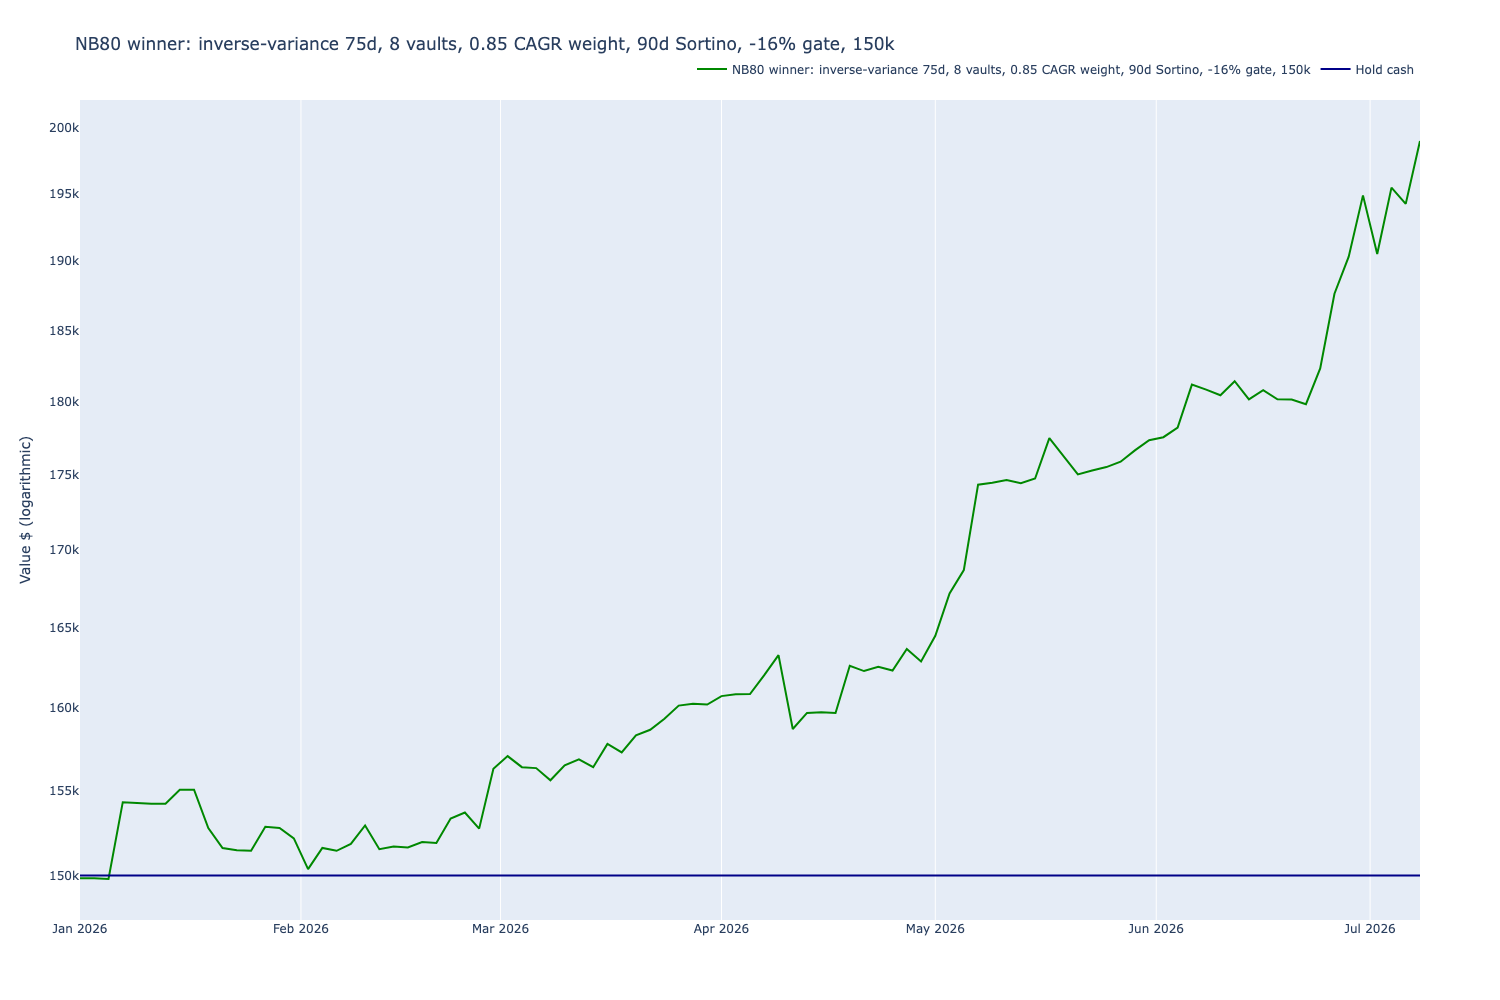

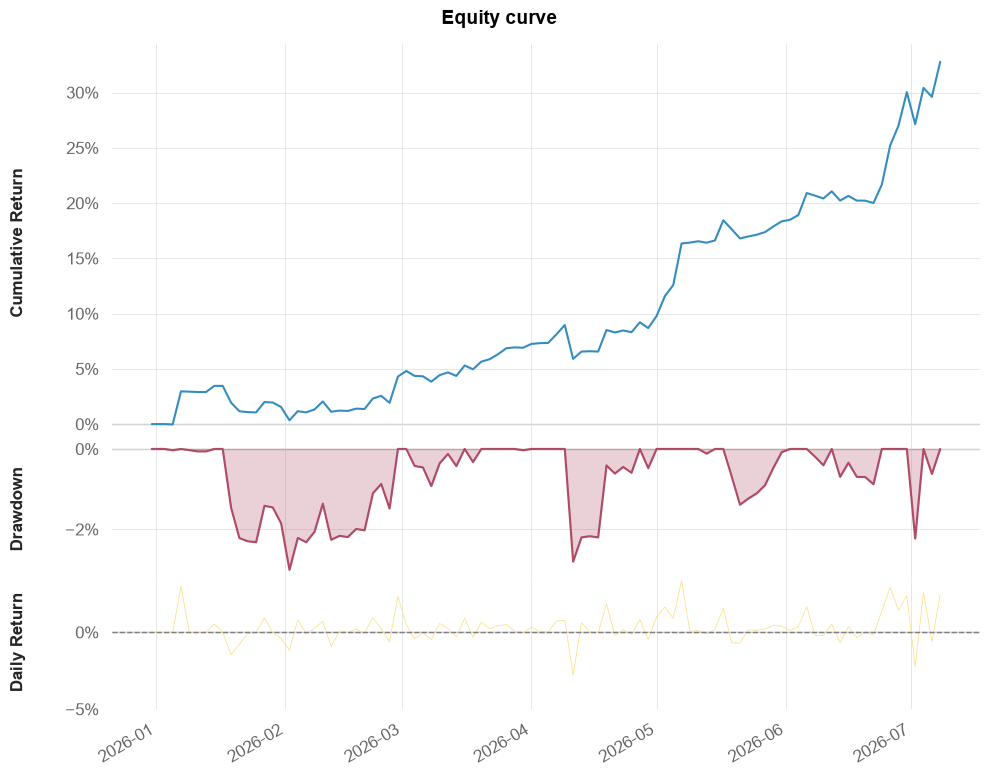

In [11]:
fig = chart_renderer.render(equity_curve_with_benchmark)
fig.show()

fig = chart_renderer.render(equity_curve_with_drawdown)
display(fig)


# Asset weights

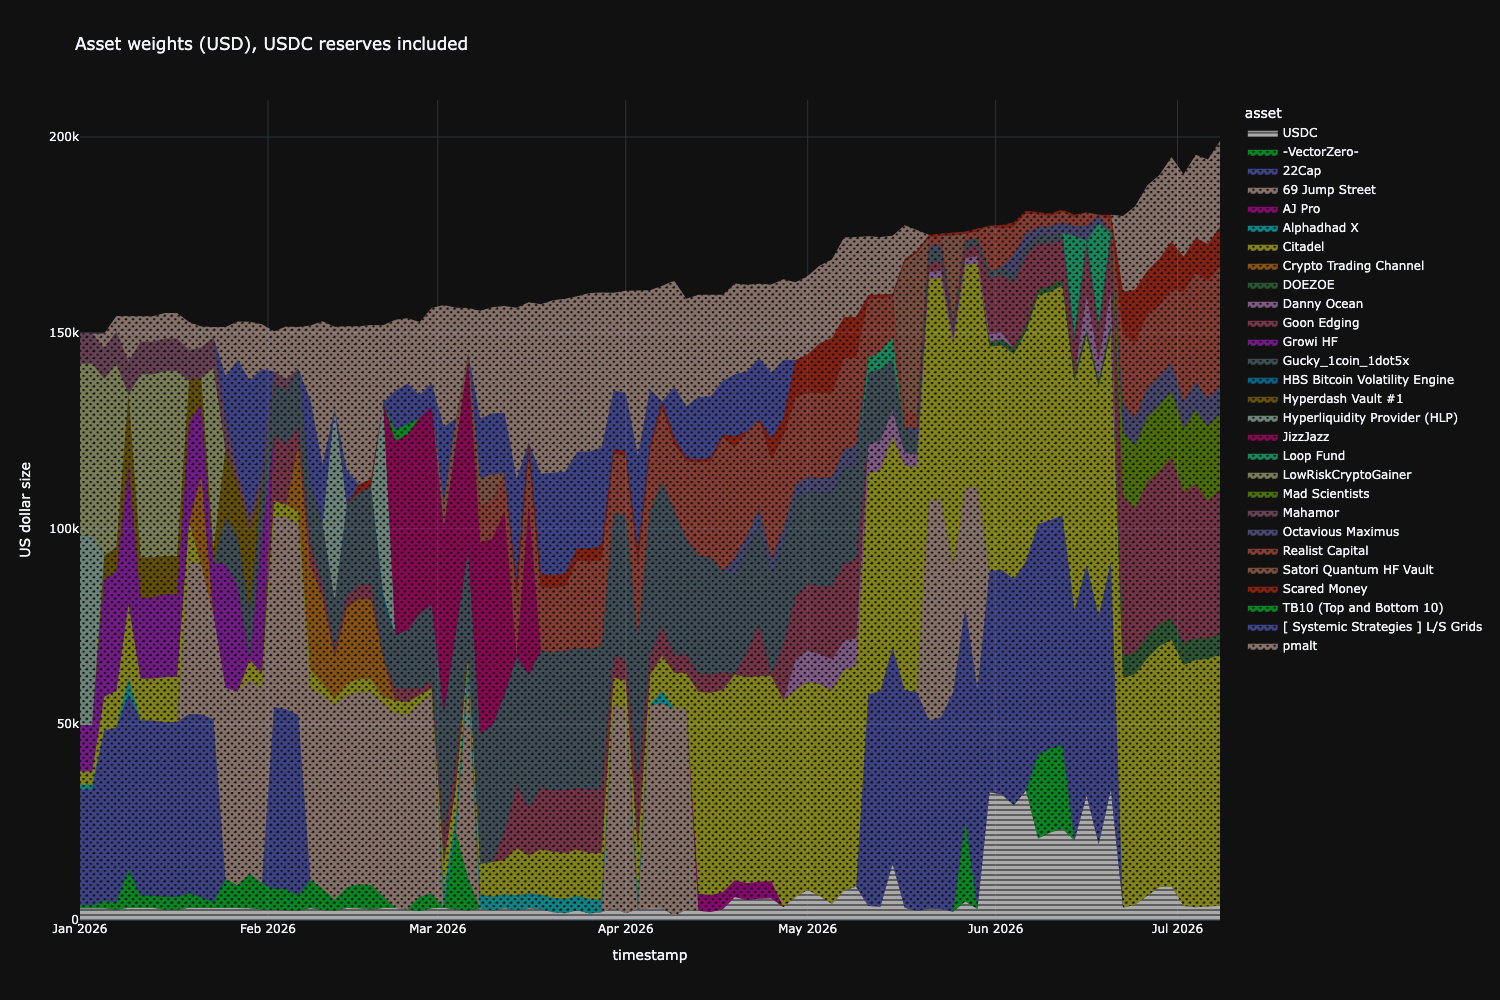

,At,Pair,Value,Address
Name,,,,
Max position (excluding USDC),2026-07-08,Citadel,"$64,348.39",
Min position (excluding USDC),2026-05-23,Scared Money,$493.46,
Mean position (excluding USDC),,,"$19,619.00",
Max position (excluding USDC),2026-06-20,Citadel,39.93%,
Min position (excluding USDC),2026-05-23,Scared Money,0.29%,
Mean position (excluding USDC),,,12.37%,
Max position (including USDC),2026-02-12,69 Jump Street,32.80%,
Min position (including USDC),2026-05-23,Scared Money,0.28%,
Mean position (including USDC),,,11.01%,


In [12]:
from tradeexecutor.utils.notebook import display_dataframe_with_html

fig = chart_renderer.render(equity_curve_by_asset)
display(fig)

display_dataframe_with_html(chart_renderer.render(weight_allocation_statistics))


# Monthly returns

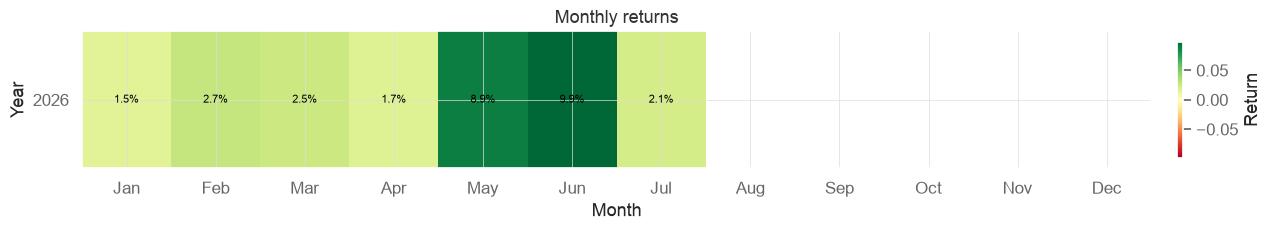

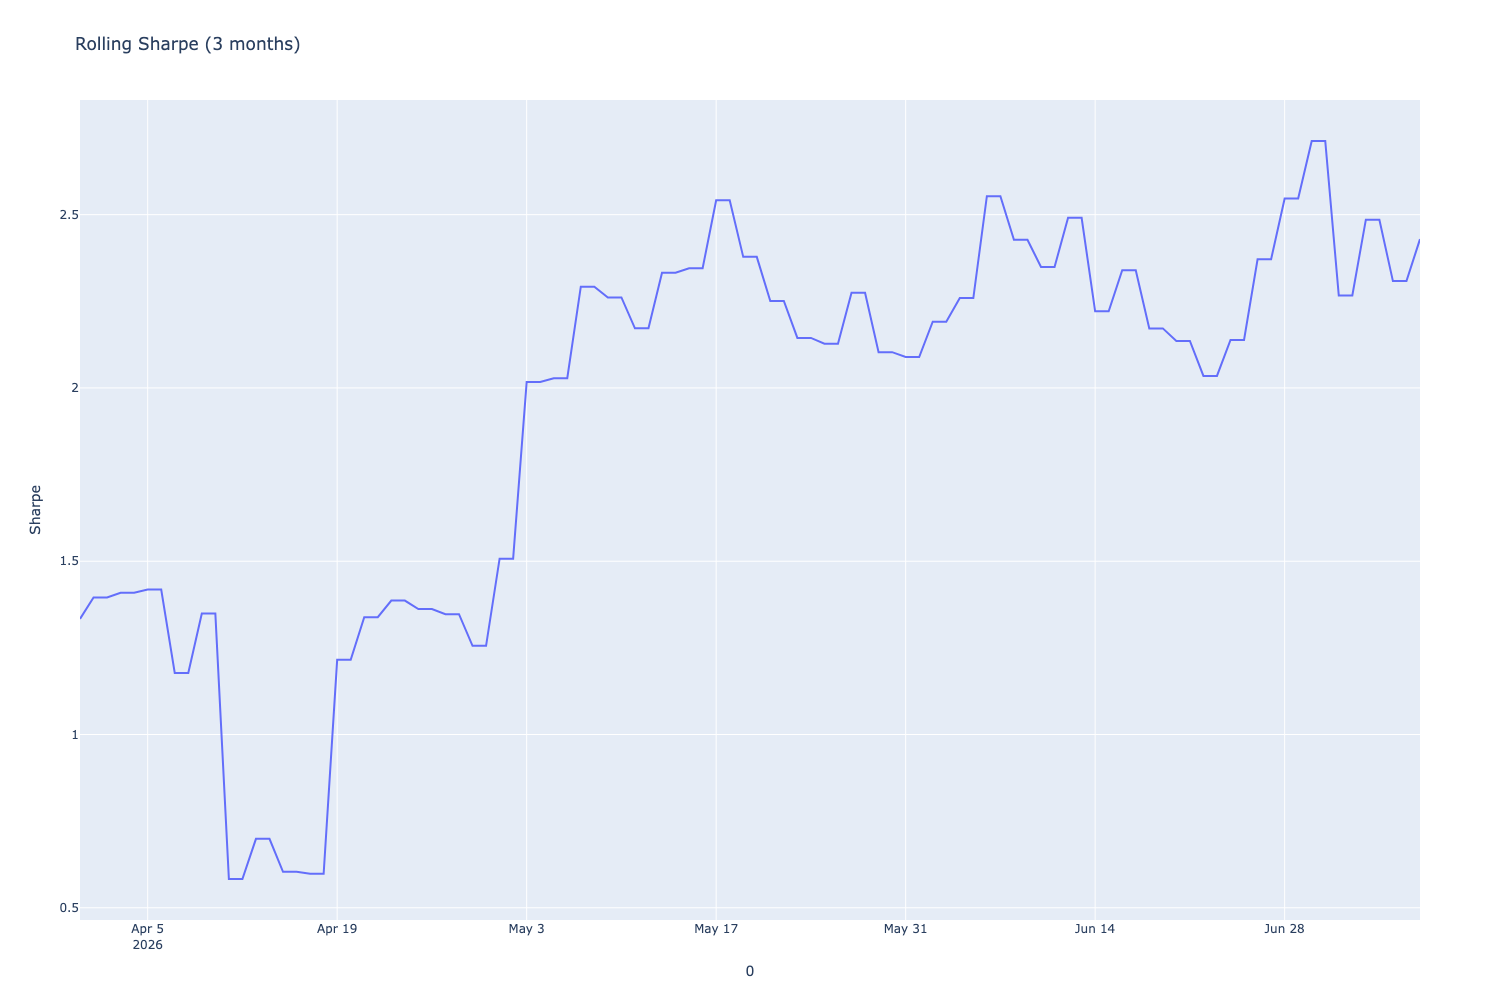

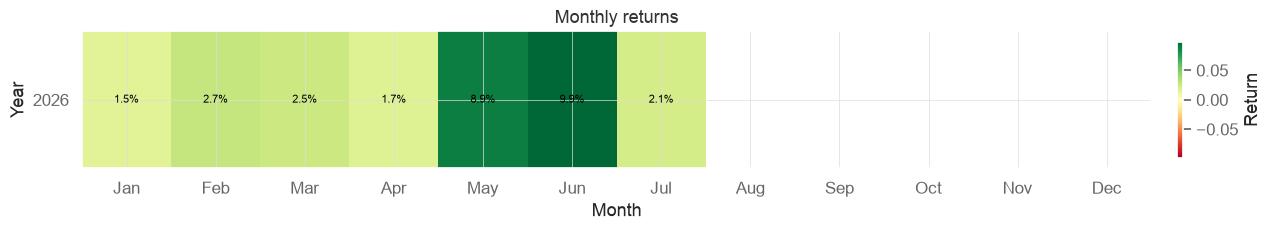

In [13]:
from tradeexecutor.visual.equity_curve import visualise_returns_over_time, calculate_rolling_sharpe
import plotly.express as px

display(visualise_returns_over_time(returns))

rolling_sharpe = calculate_rolling_sharpe(returns, freq="D", periods=90)
fig = px.line(rolling_sharpe, title="Rolling Sharpe (3 months)")
fig.update_layout(showlegend=False); fig.update_yaxes(title="Sharpe")
fig.show()


# Benchmark comparison and positions

In [14]:
from tradeexecutor.analysis.multi_asset_benchmark import compare_strategy_backtest_to_multiple_assets

display(compare_strategy_backtest_to_multiple_assets(state, strategy_universe, display=False, asset_count=2))

profit_by_position = sorted(
    ((p.get_realised_profit_usd() or 0.0, p) for p in positions),
    key=lambda x: x[0], reverse=True,
)
def pos_rows(items):
    return pd.DataFrame([{ 'Profit USD': pnl, 'Pair': p.pair.base.token_symbol,
        'Opened': p.opened_at, 'Closed': p.closed_at, 'Trades': len(p.trades) } for pnl, p in items])
print("Top 10 positions by profit:")
display(pos_rows(profit_by_position[:10]))
print("Biggest 8 losers:")
display(pos_rows(sorted(profit_by_position, key=lambda x: x[0])[:8]))

display(chart_renderer.render(positions_at_end))


,Strategy,BTC,ETH
Start Period,2026-01-01,2026-01-01,2026-01-01
End Period,2026-07-08,2026-07-08,2026-07-08
Risk-Free Rate,0,0,0
Time in Market,0.49,0.98,0.98
Cumulative Return,0.33,-0.32,-0.45
CAGR﹪,0.73,-0.52,-0.68
Sharpe,4.09,-1.28,-1.43
Prob. Sharpe Ratio,1.0,0.18,0.15
Smart Sharpe,3.92,-1.22,-1.37
Sortino,8.68,-1.72,-1.93


Top 10 positions by profit:


,Profit USD,Pair,Opened,Closed,Trades
0,9604.752617,Scared Mon,2026-04-25,2026-05-31,9
1,6112.785566,pmalt,2026-01-05,2026-05-21,55
2,4240.618457,Realist Ca,2026-03-08,2026-06-18,43
3,3241.820420,22Cap,2026-05-11,2026-06-22,15
4,3032.223042,Realist Ca,2026-06-20,NaT,9
5,2223.601168,[ Systemic,2026-01-25,2026-02-02,5
6,1917.326362,Goon Edgin,2026-02-02,2026-02-20,9
7,1526.014186,Growi HF,2026-01-01,2026-01-29,12
8,1457.346271,22Cap,2026-01-01,2026-01-25,6
9,1308.134963,Gucky_1coi,2026-01-25,2026-06-22,33


Biggest 8 losers:


,Profit USD,Pair,Opened,Closed,Trades
0,-2063.662048,Citadel,2026-01-01,2026-01-21,6
1,-1956.627725,Hyperdash,2026-01-05,2026-01-31,12
2,-1814.072447,[ Systemic,2026-02-08,2026-02-12,3
3,-1679.305210,Growi HF,2026-01-31,2026-02-02,2
4,-1323.335580,-VectorZer,2026-01-01,2026-02-22,22
5,-952.393071,Mahamor,2026-01-01,2026-02-06,3
6,-805.834926,Goon Edgin,2026-02-22,2026-03-06,6
7,-785.377461,Goon Edgin,2026-03-12,2026-04-19,15


,token,value,vault,protocol,link
position_id,,,,,
18,Citadel,64348.393974,Citadel,hyperliquid,0xda51323fe9800c8365646ad5c7ade0dd17fdc167
60,Goon Edgin,36938.476572,Goon Edging,hyperliquid,0x2431edfcb662e6ff6deab113cc91878a0b53fb0f
63,DOEZOE,5189.169147,DOEZOE,hyperliquid,0xcae0d1558b70b92ee9fd0acb20cb639c8c28ae69
70,Realist Ca,30589.007594,Realist Capital,hyperliquid,0x77fee2df7bad4f1db93052fa82bf78eaab771a16
71,Scared Mon,10244.856388,Scared Money,hyperliquid,0x5290ab34acb59cfe1371baa5782eba14433d308f
72,Mad Scient,19362.488118,Mad Scientists,hyperliquid,0x565b1c32936bdaa526947178acc95c5b08cfacc4
73,pmalt,21822.980781,pmalt,hyperliquid,0x4dec0a851849056e259128464ef28ce78afa27f6
74,Octavious,6867.512740,Octavious Maximus,hyperliquid,0x45c42fbd450b5506f8dc819d46036630fe75b81e


# Cash deployment diagnostics

Why does the strategy hold cash? Per cycle, the allocator redistributes equity a capped
position cannot take to the *remaining selected* signals, but it hard-stops at
`max_assets_in_portfolio` positions — so once all selected vaults hit their caps
(`per_position_cap_of_pool_pct` x vault TVL, or `max_concentration_pct` x investable equity),
the remainder is stranded as cash. This section quantifies which cap binds and how much
cash it strands, parsed from the per-cycle diagnostics messages.


,value
cycles,95.00
mean cash %,4.66
median cash %,1.95
max cash %,100.00
final-cycle cash %,1.74
mean deployment shortfall % of investable,0.18
cycles with shortfall > 10% of investable,0.00
mean signals pool-capped per cycle,1.96
mean signals concentration-capped per cycle,1.53
cycles where ALL selected signals were pool-capped,0.00


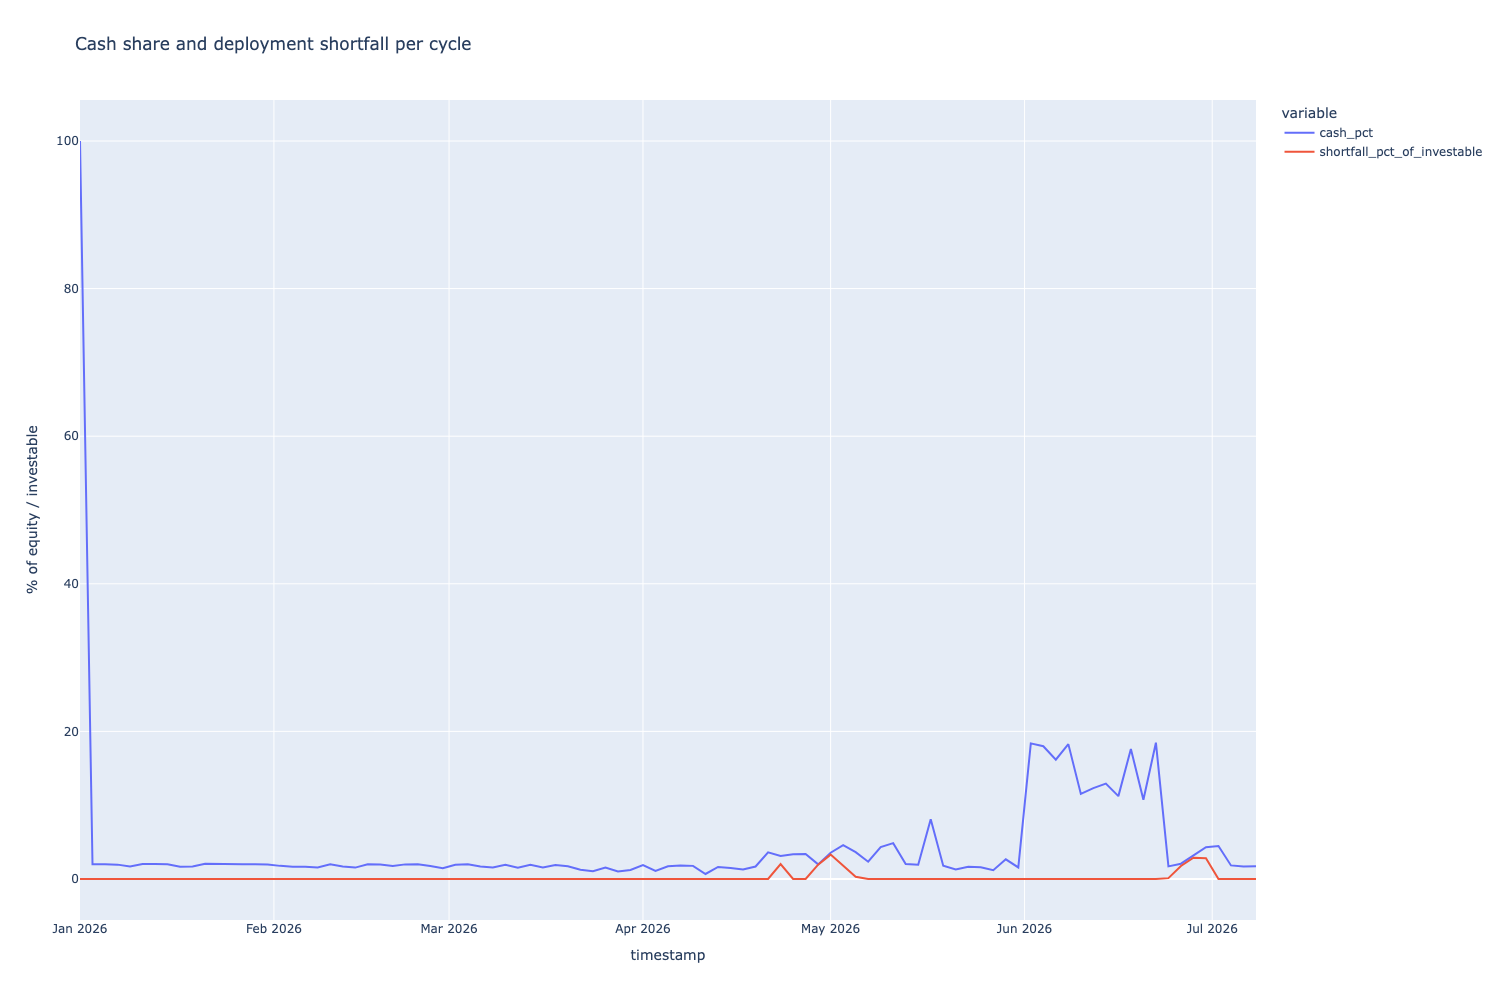

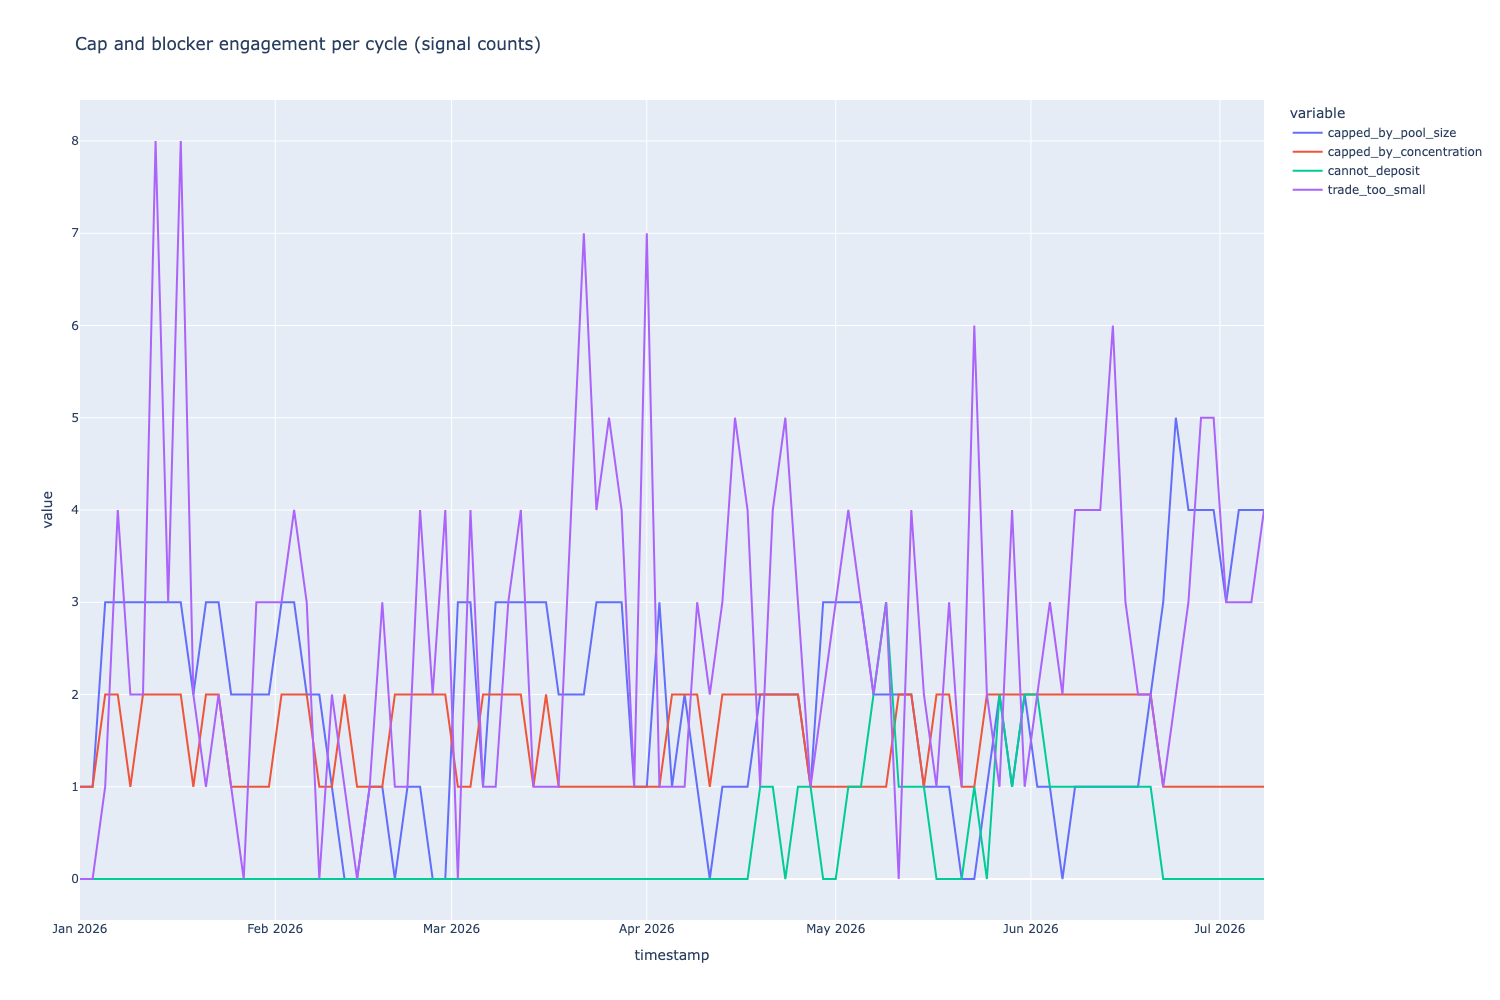

Last 30 cycles:


,cash_pct,cannot_deposit,deposit_window_skips,capped_by_pool_size,top_signal_pair
timestamp,,,,,
2026-05-11,4.9,1,0,2,22Cap-USDC
2026-05-13,2.0,1,0,2,22Cap-USDC
2026-05-15,1.9,1,0,1,22Cap-USDC
2026-05-17,8.1,0,0,1,Citadel-USDC
2026-05-19,1.8,0,0,1,Citadel-USDC
2026-05-21,1.3,0,0,0,Citadel-USDC
2026-05-23,1.7,1,0,0,Citadel-USDC
2026-05-25,1.6,0,0,1,Citadel-USDC
2026-05-27,1.2,2,0,2,Citadel-USDC


In [15]:
import re

import plotly.express as px


def extract_allocation_df(state) -> pd.DataFrame:
    """Parse per-cycle equity/cash/allocation and cap-flag counts from diagnostics messages."""
    rows = []
    for unix_ts, messages in sorted(state.visualisation.messages.items(), key=lambda item: item[0]):
        if not messages:
            continue
        message = '\n'.join(messages)

        def _usd(label):
            match = re.search(rf'{re.escape(label)}: ([0-9,.\-]+) USD', message)
            return float(match.group(1).replace(',', '')) if match else float('nan')

        def _count(label):
            match = re.search(rf'{re.escape(label)}: ([0-9]+)', message)
            return int(match.group(1)) if match else 0

        rows.append({
            'timestamp': datetime.datetime.fromtimestamp(unix_ts, datetime.timezone.utc).replace(tzinfo=None),
            'total_equity': _usd('Total equity'),
            'cash': _usd('Cash'),
            'investable': _usd('Investable equity'),
            'accepted': _usd('Accepted investable equity'),
            'discarded_liquidity': _usd('Discarded allocation because of lack of lit liquidity'),
            'candidates': _count('Candidate signals created'),
            'selected': _count('Selected survivor signals'),
            'capped_by_pool_size': _count('Signals with flag capped_by_pool_size'),
            'capped_by_concentration': _count('Signals with flag capped_by_concentration'),
            'cannot_deposit': _count('Signals with flag cannot_deposit'),
            'deposit_window_skips': _count('Candidates skipped for closed deposit window'),
            'trade_too_small': _count('Signals with flag individual_trade_size_too_small'),
            'top_signal_pair': (re.search(r'Top signal pair: (\S+)', message).group(1)
                                if re.search(r'Top signal pair: (\S+)', message) else None),
        })
    return pd.DataFrame(rows).set_index('timestamp')


alloc_df = extract_allocation_df(state)
alloc_df['cash_pct'] = alloc_df['cash'] / alloc_df['total_equity'] * 100
alloc_df['deployment_shortfall'] = alloc_df['investable'] - alloc_df['accepted']
alloc_df['shortfall_pct_of_investable'] = alloc_df['deployment_shortfall'] / alloc_df['investable'] * 100

deployment_summary = pd.Series({
    'cycles': len(alloc_df),
    'mean cash %': alloc_df['cash_pct'].mean(),
    'median cash %': alloc_df['cash_pct'].median(),
    'max cash %': alloc_df['cash_pct'].max(),
    'final-cycle cash %': alloc_df['cash_pct'].iloc[-1],
    'mean deployment shortfall % of investable': alloc_df['shortfall_pct_of_investable'].mean(),
    'cycles with shortfall > 10% of investable': int((alloc_df['shortfall_pct_of_investable'] > 10).sum()),
    'mean signals pool-capped per cycle': alloc_df['capped_by_pool_size'].mean(),
    'mean signals concentration-capped per cycle': alloc_df['capped_by_concentration'].mean(),
    'cycles where ALL selected signals were pool-capped': int(
        ((alloc_df['capped_by_pool_size'] >= alloc_df['selected']) & (alloc_df['selected'] > 0)).sum()
    ),
    'cycles with < 5 gated candidates': int((alloc_df['candidates'] < int(Parameters.max_assets_in_portfolio)).sum()),
    'cycles with a cannot_deposit signal (closed deposit window)': int((alloc_df['cannot_deposit'] > 0).sum()),
    'cycles skipping closed-window candidates at selection': int((alloc_df['deposit_window_skips'] > 0).sum()),
    'total closed-window candidates skipped at selection': int(alloc_df['deposit_window_skips'].sum()),
    'mean cash % when cannot_deposit engaged': alloc_df.loc[alloc_df['cannot_deposit'] > 0, 'cash_pct'].mean(),
    'mean cash % when no cannot_deposit': alloc_df.loc[alloc_df['cannot_deposit'] == 0, 'cash_pct'].mean(),
}, name='value')
display(deployment_summary.to_frame().round(2))

fig = px.line(alloc_df[['cash_pct', 'shortfall_pct_of_investable']], title='Cash share and deployment shortfall per cycle')
fig.update_yaxes(title='% of equity / investable')
fig.show()

fig = px.line(alloc_df[['capped_by_pool_size', 'capped_by_concentration', 'cannot_deposit', 'trade_too_small']], title='Cap and blocker engagement per cycle (signal counts)')
fig.show()

print('Last 30 cycles:')
display(alloc_df[['cash_pct', 'cannot_deposit', 'deposit_window_skips', 'capped_by_pool_size', 'top_signal_pair']].tail(30).round(1))


In [16]:
# Shared analysis helpers used by every grid in this notebook.
#
# Kept in their own cell deliberately: earlier variants defined these inside a grid cell, and
# replacing that grid in the next variant silently removed them.
from tradeexecutor.analysis.weights import calculate_asset_weights, visualise_weights


def deployment_stats(state_) -> dict:
    """Cash, deployment shortfall and cap-binding counts for one run.

    `extract_allocation_df()` returns the raw per-cycle fields; `cash_pct` and the shortfall
    percentage are derived from them above rather than inside that function, so recompute here.
    """
    alloc = extract_allocation_df(state_)
    if not len(alloc):
        return {}
    cash_pct = alloc["cash"] / alloc["total_equity"] * 100
    shortfall_pct = (alloc["investable"] - alloc["accepted"]) / alloc["investable"] * 100
    return {
        "Mean cash %": float(cash_pct.mean()),
        "Deployment shortfall %": float(shortfall_pct.mean()),
        "Cycles >10% unplaced": int((shortfall_pct > 10).sum()),
        "Pool-capped per cycle": float(alloc["capped_by_pool_size"].mean()),
        "Concentration-capped per cycle": float(alloc["capped_by_concentration"].mean()),
    }


def weight_concentration_stats(weights_series: pd.Series) -> dict:
    """Largest weight and effective position count from an asset weight timeline.

    `calculate_asset_weights()` returns a (timestamp, asset) MultiIndex of USD values, so normalise
    within each timestamp before measuring concentration. Reserves are dropped: cash is not a
    position and would flatter the diversification measure exactly when the strategy fails to
    deploy.
    """
    frame = weights_series.unstack(level=1).fillna(0.0)
    for reserve in ("USDC", "USDT", "USDC.e", "USDT0"):
        if reserve in frame.columns:
            frame = frame.drop(columns=[reserve])
    totals = frame.sum(axis=1)
    frame = frame.loc[totals > 0]
    if not len(frame):
        return {}
    normalised = frame.div(frame.sum(axis=1), axis=0)
    herfindahl = (normalised ** 2).sum(axis=1)
    return {
        "Mean largest weight": float(normalised.max(axis=1).mean()),
        "Max largest weight": float(normalised.max(axis=1).max()),
        "Effective positions": float((1.0 / herfindahl).mean()),
        "Mean held": float((normalised > 0.005).sum(axis=1).mean()),
    }


## End-of-backtest drill-down

The held vaults at the end, their TVL, and the pool cap each one imposes. If the sum of
pool caps is below investable equity, the cash pile is structural: the five selected
vaults simply cannot absorb the bankroll at a 15% TVL share.


In [17]:
#: Label derives from the configured cap - it was hardcoded to "15%" in the ancestor
#: notebooks, which silently mislabels any variant that changes the pool cap.
POOL_CAP_LABEL = f"Pool cap ({Parameters.per_position_cap_of_pool_pct:.0%} of TVL) USD"

final_rows = []
for position in state.portfolio.open_positions.values():
    pair = position.pair
    try:
        tvl_series = indicator_data.get_indicator_series('tvl', pair=pair)
        last_tvl = float(tvl_series.dropna().iloc[-1])
    except Exception:
        last_tvl = float('nan')
    final_rows.append({
        'Vault': pair.base.token_symbol,
        'Position value USD': float(position.get_value()),
        'Vault TVL USD': last_tvl,
        POOL_CAP_LABEL: last_tvl * float(Parameters.per_position_cap_of_pool_pct),
    })
final_positions_df = pd.DataFrame(final_rows).sort_values('Position value USD', ascending=False)
display(final_positions_df.round(0))

final_cycle = alloc_df.iloc[-1]
print(f"Final cycle equity: {final_cycle['total_equity']:,.0f} USD, cash: {final_cycle['cash']:,.0f} USD ({final_cycle['cash_pct']:.1f}%)")
print(f"Investable (98% target): {final_cycle['investable']:,.0f} USD, accepted by caps: {final_cycle['accepted']:,.0f} USD")
print(f"Sum of pool caps across held vaults: {final_positions_df[POOL_CAP_LABEL].sum():,.0f} USD")

print()
print('Last cycle raw diagnostics:')
last_ts = max(state.visualisation.messages)
print('\n'.join(state.visualisation.messages[last_ts]))


,Vault,Position value USD,Vault TVL USD,Pool cap (33% of TVL) USD
0,Citadel,64348.0,558891.0,184434.0
1,Goon Edgin,36938.0,108169.0,35696.0
3,Realist Ca,30589.0,485292.0,160146.0
6,pmalt,21823.0,513987.0,169616.0
5,Mad Scient,19362.0,59388.0,19598.0
4,Scared Mon,10245.0,50278.0,16592.0
7,Octavious,6868.0,20166.0,6655.0
2,DOEZOE,5189.0,15752.0,5198.0


Final cycle equity: 198,978 USD, cash: 3,460 USD (1.7%)
Investable (98% target): 194,999 USD, accepted by caps: 194,999 USD
Sum of pool caps across held vaults: 597,935 USD

Last cycle raw diagnostics:
Cycle: #95
Rebalanced: 👍
Open/about to open positions: 8
Max position value change: 2,922.26 USD
Rebalance threshold: 75.00 USD
Trades decided: 4
Pairs meeting inclusion criteria: 199
Pairs meeting TVL inclusion criteria: 202
Candidate signals created: 195
Selected survivor signals: 8
Candidates skipped for closed deposit window: 0
Weighting method: inverse_variance
Minimum hold days: 1
Signals blocked by minimum hold: 0
CAGR lookback days: 360
Sharpe lookback days: 90
CAGR weight (blend): 0.85
Total equity: 198,978.16 USD
Cash: 3,460.48 USD
Redeemable capital: 195,517.69 USD
Pending redemptions: 0.00 USD
Investable equity: 194,998.60 USD
Accepted investable equity: 194,998.60 USD
Allocated to signals: 194,998.60 USD
Discarded allocation because of lack of lit liquidity: 49,215.85 USD
Re

# Robustness diagnostics

In [18]:
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)
from tradeexecutor.curator import is_quarantined


def return_metrics(return_series: pd.Series) -> dict:
    return_series = return_series.dropna()
    cagr = float(calculate_cagr(return_series))
    max_drawdown = float(calculate_max_drawdown(return_series))
    return {
        'Cumulative return': float((1.0 + return_series).prod() - 1.0),
        'CAGR': cagr,
        'Sharpe': float(calculate_sharpe(return_series, periods=365)),
        'Sortino': float(calculate_sortino(return_series, periods=365)),
        'Max drawdown': max_drawdown,
    }


daily_returns = calculate_returns(equity).resample('1D').sum(min_count=1).fillna(0.0)
profitable_returns = daily_returns[daily_returns > 0.0]
profitable_outlier_cutoff = profitable_returns.quantile(0.95)
profitable_outlier_mask = (daily_returns > 0.0) & (daily_returns > profitable_outlier_cutoff)
returns_without_best_days = daily_returns.mask(profitable_outlier_mask, 0.0)

robustness_df = pd.DataFrame([
    {'Scenario': 'Original', **return_metrics(daily_returns)},
    {
        'Scenario': 'Largest 5% profitable daily returns neutralised',
        **return_metrics(returns_without_best_days),
    },
]).set_index('Scenario')
display(robustness_df.style.format({
    'Cumulative return': '{:.2%}',
    'CAGR': '{:.2%}',
    'Sharpe': '{:.2f}',
    'Sortino': '{:.2f}',
    'Max drawdown': '{:.2%}',
}))

best_day = pd.Timestamp(daily_returns.idxmax()).normalize()
daily_return_diagnostics_df = pd.DataFrame([{
    'Best day': best_day,
    'Best-day return': float(daily_returns.max()),
    'Worst day': pd.Timestamp(daily_returns.idxmin()).normalize(),
    'Worst-day return': float(daily_returns.min()),
    'Best-day share of positive daily returns': float(daily_returns.max() / profitable_returns.sum()),
    'Daily-return skew': float(daily_returns.skew()),
    'Daily excess kurtosis': float(daily_returns.kurtosis()),
    'Neutralised profitable days': int(profitable_outlier_mask.sum()),
    'Neutralisation cutoff': float(profitable_outlier_cutoff),
}])
display(daily_return_diagnostics_df.style.format({
    'Best-day return': '{:.2%}',
    'Worst-day return': '{:.2%}',
    'Best-day share of positive daily returns': '{:.1%}',
    'Daily-return skew': '{:.2f}',
    'Daily excess kurtosis': '{:.2f}',
    'Neutralisation cutoff': '{:.2%}',
}))

valuation_rows = []
for position in positions:
    for update in position.valuation_updates:
        valuation_day = pd.Timestamp(update.valued_at).normalize()
        if valuation_day != best_day or update.old_value is None:
            continue
        valuation_rows.append({
            'Vault': position.pair.base.token_symbol,
            'Vault address': position.pair.pool_address,
            'Valuation change USD': float(update.new_value - update.old_value),
            'Curator-quarantined on best day': is_quarantined(
                position.pair.pool_address,
                best_day.to_pydatetime(),
            ),
        })

best_day_valuation_df = pd.DataFrame(valuation_rows)
if len(best_day_valuation_df):
    best_day_valuation_df = best_day_valuation_df.sort_values('Valuation change USD', ascending=False)
display(best_day_valuation_df.head(12).style.format({'Valuation change USD': '${:,.0f}'}))



from tradeexecutor.curator.curator import QUARANTINE_PERIODS

quarantine_overlap_rows = []
for position in positions:
    position_address = position.pair.pool_address.lower()
    position_end = position.closed_at or Parameters.backtest_end
    for address, quarantine_start, quarantine_end, reason in QUARANTINE_PERIODS:
        if position_address != address.lower():
            continue
        if position.opened_at <= quarantine_end and position_end >= quarantine_start:
            quarantine_overlap_rows.append({
                'Vault': position.pair.base.token_symbol,
                'Opened': position.opened_at,
                'Closed': position.closed_at,
                'Quarantine start': quarantine_start,
                'Quarantine end': quarantine_end,
                'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
                'Reason': reason,
            })

quarantine_overlap_df = pd.DataFrame(quarantine_overlap_rows)
display(quarantine_overlap_df.style.format({'Realised profit USD': '${:,.0f}'}).set_caption('Curator quarantine overlap audit'))



best_day_position_rows = []
for position in positions:
    position_end = position.closed_at or Parameters.backtest_end
    if not (position.opened_at <= best_day.to_pydatetime() <= position_end):
        continue
    candles = strategy_universe.data_universe.candles.get_candles_by_pair(position.pair.internal_id)
    candle_closes = candles.set_index('timestamp')['close'].sort_index()
    # The equity curve is sampled once per strategy cycle, so on a 2-day cadence the "best day"
    # booked a two-day move. Measure each vault over the same span - comparing against yesterday's
    # close attributes only the final day and can show every holding flat while the portfolio jumps.
    equity_sample_days = pd.DatetimeIndex(equity.index).normalize()
    earlier_samples = equity_sample_days[equity_sample_days < best_day]
    span_start = earlier_samples[-1] if len(earlier_samples) else best_day - pd.Timedelta(days=1)
    close_on_best_day = candle_closes.loc[candle_closes.index <= best_day].iloc[-1]
    close_before_best_day = candle_closes.loc[candle_closes.index <= span_start].iloc[-1]
    best_day_position_rows.append({
        'Vault': position.pair.base.token_symbol,
        'Position opened': position.opened_at,
        'Position closed': position.closed_at,
        'Vault return over the best step': float(close_on_best_day / close_before_best_day - 1.0),
        'Realised profit USD': float(position.get_realised_profit_usd() or 0.0),
        'Curator-quarantined on best day': is_quarantined(
            position.pair.pool_address,
            best_day.to_pydatetime(),
        ),
    })

best_day_positions_df = pd.DataFrame(best_day_position_rows).sort_values(
    'Vault return over the best step',
    ascending=False,
)
display(
    best_day_positions_df.style.format({
        'Vault return over the best step': '{:.2%}',
        'Realised profit USD': '${:,.0f}',
    }).set_caption('Position moves on the best portfolio day')
)


,Cumulative return,CAGR,Sharpe,Sortino,Max drawdown
Scenario,,,,,
Original,32.78%,73.41%,4.09,8.68,-3.01%
Largest 5% profitable daily returns neutralised,21.22%,45.29%,3.26,5.90,-3.01%


,Best day,Best-day return,Worst day,Worst-day return,Best-day share of positive daily returns,Daily-return skew,Daily excess kurtosis,Neutralised profitable days,Neutralisation cutoff
0,2026-05-07 00:00:00,3.34%,2026-04-11 00:00:00,-2.80%,7.3%,1.40,7.38,3,2.70%


,Vault,Position opened,Position closed,Vault return over the best step,Realised profit USD,Curator-quarantined on best day
2,Octavious,2026-04-19 00:00:00,2026-05-11 00:00:00,12.96%,$743,False
3,pmalt,2026-01-05 00:00:00,2026-05-21 00:00:00,1.01%,"$6,113",False
7,Gucky_1coi,2026-01-25 00:00:00,2026-06-22 00:00:00,0.17%,"$1,308",False
0,Citadel,2026-01-29 00:00:00,NaT,-0.00%,$-293,False
4,Scared Mon,2026-04-25 00:00:00,2026-05-31 00:00:00,-1.49%,"$9,605",False
5,Danny Ocea,2026-04-29 00:00:00,2026-06-04 00:00:00,-2.58%,$-711,False
6,Realist Ca,2026-03-08 00:00:00,2026-06-18 00:00:00,-3.03%,"$4,241",False
1,Goon Edgin,2026-04-27 00:00:00,2026-05-11 00:00:00,-5.38%,$605,False


# Parameter ablation

Seven parameters were searched to produce this configuration. This section moves **one at a time**,
holding everything else at the winner's value, and measures what each is worth in Sharpe and CAGR.

Two things make an ablation on this strategy less straightforward than it looks:

- **Some parameters change the indicators, not just the decision rule.** `cagr_weight`,
  `cagr_lookback_days`, `sharpe_lookback_days` and `inverse_vol_window` all feed indicator
  definitions, so a variant touching them needs its indicators recomputed rather than reusing the
  baseline's. `gate_threshold`, the caps and the softband are applied inside `decide_trades` and
  can reuse them.
- **Every run is scored on a daily grid.** The equity curve is sampled once per 2-day cycle;
  annualising that directly would inflate Sharpe by `sqrt(2)` relative to a daily-cadence run. The
  helper resamples first, matching the basis used in the robustness cell above.

Each variant is screened for destroyed and stranded capital before its metrics are reported. A
variant that fails the screen is shown but should not be compared on return.

The comparison is **directional, not a re-search**. A parameter that hurts when moved to one
neighbouring value has not been proven optimal - it has been proven locally non-flat.


In [19]:
from tradeexecutor.backtest.backtest_execution import BacktestExecutionFailed
from tradeexecutor.statistics.key_metric import (
    calculate_cagr,
    calculate_max_drawdown,
    calculate_sharpe,
    calculate_sortino,
)


def summarise_run(label: str, equity_curve: pd.Series, state_) -> dict:
    """Headline metrics for one backtest run, on a daily basis.

    Taken unchanged from NB76 so the numbers are directly comparable across the chain. The equity
    curve is sampled once per strategy cycle, so a 2-day cadence produces one observation every 48
    hours; annualising that with ``periods=365`` would overstate Sharpe and Sortino by ``sqrt(2)``.
    Resampling onto a daily grid turns each 2-day step into one non-zero and one zero day, which
    annualises correctly.
    """
    return_series = calculate_returns(equity_curve).resample("1D").sum(min_count=1).fillna(0.0).dropna()
    trades = list(state_.portfolio.get_all_trades())
    run_positions = [p for p in state_.portfolio.get_all_positions() if not p.is_credit_supply()]
    return {
        "Final equity": float(equity_curve.iloc[-1]),
        "CAGR": float(calculate_cagr(return_series)),
        "Sharpe": float(calculate_sharpe(return_series, periods=365)),
        "Sortino": float(calculate_sortino(return_series, periods=365)),
        "Max drawdown": float(calculate_max_drawdown(return_series)),
        "Positions": len(run_positions),
        "Trades": len(trades),
    }


#: Parameters that feed an indicator definition rather than only `decide_trades`.
#:
#: A variant touching any of these cannot reuse the baseline's indicator combinations - the
#: indicator itself is parameterised, so reusing them would silently score the variant with the
#: baseline's signal and make the ablation meaningless.
INDICATOR_PARAMS = {
    "cagr_weight",
    "cagr_lookback_days",
    "sharpe_lookback_days",
    "inverse_vol_window",
    "gate_lookback_days",
    "selection_score_indicator",
    "min_tvl_usd",
}


def run_variant(label: str, overrides: dict) -> dict:
    """Run one ablation and return its metrics, or a crash marker."""
    run_parameters = StrategyParameters.from_dict(dict(parameters))
    for key, value in overrides.items():
        run_parameters[key] = value

    if set(overrides) & INDICATOR_PARAMS:
        run_indicators = calculate_and_load_indicators_inline(
            strategy_universe=strategy_universe,
            create_indicators=indicators.create_indicators,
            parameters=run_parameters,
        )
        combinations = run_indicators.indicator_combinations
    else:
        combinations = indicator_data.indicator_combinations

    try:
        run_result = run_backtest_inline(
            name=label,
            engine_version="0.5",
            decide_trades=decide_trades,
            indicator_combinations=combinations,
            cycle_duration=Parameters.cycle_duration,
            client=client,
            universe=strategy_universe,
            parameters=run_parameters,
            max_workers=1,
            start_at=Parameters.backtest_start,
            end_at=Parameters.backtest_end,
        )
    except BacktestExecutionFailed as exc:
        print(f"  {label}: CRASHED - {type(exc).__name__}")
        return {"Variant": label, "Crashed": True}

    run_state = run_result.state
    run_equity = calculate_equity_curve(run_state)
    row = {"Variant": label, "Crashed": False}
    row.update(summarise_run(label, run_equity, run_state))
    run_audit = audit_portfolio(run_state.portfolio)
    row["Destroyed"] = run_audit["destroyed"]
    row["Stranded"] = run_audit["stranded"]
    print(f"  {label}: CAGR {row['CAGR']:.2%}  Sharpe {row['Sharpe']:.2f}  "
          f"destroyed {run_audit['destroyed']}  stranded {run_audit['stranded']}")
    return row


#: (group, label, overrides). The baseline is the NB80 winner, already run above.
#:
#: `gate_threshold = -1.0` switches the gate off rather than loosening it: a trailing 14-day return
#: of -100% is unreachable, so no vault is ever ejected by momentum.
ABLATIONS = [
    ("Selection score", "cagr_weight 0.85 -> 1.00  (Sortino leg removed)", {"cagr_weight": 1.0}),
    ("Selection score", "cagr_weight 0.85 -> 0.50", {"cagr_weight": 0.5}),
    ("Selection score", "cagr_weight 0.85 -> 0.00  (CAGR leg removed)", {"cagr_weight": 0.0}),
    ("Selection score", "Sortino leg -> Sharpe leg", {"selection_score_indicator": "cagr_sharpe_weight"}),
    ("Selection score", "cagr_lookback 360 -> 270", {"cagr_lookback_days": 270}),
    ("Selection score", "Sortino window 90 -> 45", {"sharpe_lookback_days": 45}),
    ("Gate", "gate -0.16 -> off", {"gate_threshold": -1.0}),
    ("Gate", "gate -0.16 -> -0.08  (NB77 optimum)", {"gate_threshold": -0.08}),
    ("Sizing", "inverse_variance -> inverse_vol", {"weighting_method": "inverse_vol"}),
    ("Sizing", "inverse_variance -> equal weight", {"weighting_method": "equal"}),
    ("Sizing", "vol window 75 -> 45", {"inverse_vol_window": 45}),
    ("Sizing", "vol window 75 -> 90", {"inverse_vol_window": 90}),
    ("Capacity", "8 vaults -> 6", {"max_assets_in_portfolio": 6}),
    ("Capacity", "concentration 33% -> 50%", {"max_concentration_pct": 0.50}),
    ("Capacity", "concentration 33% -> 25%", {"max_concentration_pct": 0.25}),
    ("Capacity", "pool cap 33% -> 25%", {"per_position_cap_of_pool_pct": 0.25}),
    ("Frictions", "softband $750 -> off", {"sell_rebalance_min_threshold_usd": 0.0}),
]

baseline_row = {"Variant": "Baseline (NB80 winner)", "Crashed": False}
baseline_row.update(summarise_run("baseline", equity, state))
baseline_row["Destroyed"] = audit["destroyed"]
baseline_row["Stranded"] = audit["stranded"]
print(f"  baseline: CAGR {baseline_row['CAGR']:.2%}  Sharpe {baseline_row['Sharpe']:.2f}")

ablation_rows = [baseline_row]
ablation_groups = {"Baseline (NB80 winner)": "-"}
for group, label, overrides in ABLATIONS:
    ablation_groups[label] = group
    ablation_rows.append(run_variant(label, overrides))

ablation_df = pd.DataFrame(ablation_rows).set_index("Variant")
ablation_df.insert(0, "Group", [ablation_groups[i] for i in ablation_df.index])


  baseline: CAGR 73.41%  Sharpe 4.09


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   0%|          | 0/2008 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   6%|▌         | 125/2008 [00:00<00:01, 1237.28it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  13%|█▎        | 258/2008 [00:00<00:01, 1288.75it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  20%|█▉        | 396/2008 [00:00<00:01, 1322.50it/s]

...

  8 vaults -> 6: CAGR 62.36%  Sharpe 2.17  destroyed 0  stranded 0


  concentration 33% -> 50%: CAGR 49.74%  Sharpe 3.65  destroyed 0  stranded 0


  concentration 33% -> 25%: CAGR 73.38%  Sharpe 3.49  destroyed 0  stranded 0


  pool cap 33% -> 25%: CAGR 69.70%  Sharpe 3.79  destroyed 0  stranded 0


  softband $750 -> off: CAGR 73.46%  Sharpe 4.10  destroyed 0  stranded 0


In [20]:
# Contribution of each parameter, as the change from the baseline when it is moved.
#
# The sign convention is "what moving this parameter does", so a negative delta means the
# baseline value is better on that metric.
base = ablation_df.loc["Baseline (NB80 winner)"]
table = ablation_df.copy()
table["d Sharpe"] = table["Sharpe"] - base["Sharpe"]
table["d CAGR"] = table["CAGR"] - base["CAGR"]
table["d Trades"] = table["Trades"] - base["Trades"]

sound = table[(~table["Crashed"].astype(bool)) & (table["Destroyed"] == 0) & (table["Stranded"] == 0)]
excluded = table[table["Crashed"].astype(bool) | (table["Destroyed"] > 0) | (table["Stranded"] > 0)]

display(
    sound.sort_values("d Sharpe")[
        ["Group", "CAGR", "Sharpe", "Sortino", "Max drawdown", "Trades", "d Sharpe", "d CAGR", "d Trades"]
    ].style.format({
        "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Max drawdown": "{:.2%}",
        "Trades": "{:.0f}", "d Sharpe": "{:+.2f}", "d CAGR": "{:+.2%}", "d Trades": "{:+.0f}",
    }).background_gradient(subset=["d Sharpe"], cmap="RdYlGn")
    .set_caption("One parameter moved at a time, worst for Sharpe first")
)

if len(excluded):
    print(f"{len(excluded)} variant(s) excluded - crashed, or destroyed/stranded capital:")
    display(excluded[["Group", "Crashed", "Destroyed", "Stranded"]])

# How much does each *group* of parameters move the result at all? A group whose worst and best
# variant sit within noise of each other is a group the search did not need to explore.
span = sound[sound.index != "Baseline (NB80 winner)"].groupby("Group").agg(
    variants=("Sharpe", "size"),
    worst_d_sharpe=("d Sharpe", "min"),
    best_d_sharpe=("d Sharpe", "max"),
)
span["span"] = span["best_d_sharpe"] - span["worst_d_sharpe"]
display(
    span.sort_values("span", ascending=False).style.format({
        "worst_d_sharpe": "{:+.2f}", "best_d_sharpe": "{:+.2f}", "span": "{:.2f}",
    }).set_caption("Sharpe span within each parameter group - how much the axis matters at all")
)


,Group,CAGR,Sharpe,Sortino,Max drawdown,Trades,d Sharpe,d CAGR,d Trades
Variant,,,,,,,,,
cagr_weight 0.85 -> 0.00 (CAGR leg removed),Selection score,-3.98%,-0.27,-0.35,-10.70%,499,-4.36,-77.39%,-42
cagr_lookback 360 -> 270,Selection score,-9.39%,-0.26,-0.32,-26.34%,494,-4.35,-82.80%,-47
inverse_variance -> equal weight,Sizing,23.29%,1.30,2.02,-10.98%,452,-2.79,-50.11%,-89
cagr_weight 0.85 -> 0.50,Selection score,21.72%,1.85,3.23,-2.88%,495,-2.24,-51.68%,-46
gate -0.16 -> -0.08 (NB77 optimum),Gate,29.03%,2.11,3.47,-3.38%,559,-1.98,-44.38%,+18
8 vaults -> 6,Capacity,62.36%,2.17,3.45,-11.91%,406,-1.92,-11.04%,-135
cagr_weight 0.85 -> 1.00 (Sortino leg removed),Selection score,50.70%,2.76,4.94,-5.89%,490,-1.33,-22.71%,-51
gate -0.16 -> off,Gate,58.66%,2.79,4.66,-6.94%,508,-1.30,-14.74%,-33
vol window 75 -> 90,Sizing,51.51%,3.27,6.15,-4.10%,545,-0.82,-21.90%,+4


,variants,worst_d_sharpe,best_d_sharpe,span
Group,,,,
Selection score,6,-4.36,+0.07,4.43
Sizing,4,-2.79,-0.78,2.01
Capacity,4,-1.92,-0.30,1.62
Gate,2,-1.98,-1.30,0.68
Frictions,1,+0.01,+0.01,0.00


# Can the strategy be simplified?

An ablation says what each parameter is worth on its own. It does not say whether the parameters
that look inert can be removed *together* - interactions are exactly what a one-at-a-time sweep
cannot see.

Four of the ablations above do not merely change a value, they **remove a degree of freedom**:

| Simplification | What it deletes |
|---|---|
| `cagr_weight` -> 1.0 | the whole Sortino leg, and with it `sharpe_lookback_days` |
| gate off | `gate_threshold` and `gate_lookback_days` |
| equal weighting | the sizing rule, and with it `inverse_vol_window` and `weighting_exponent` |
| softband off | `sell_rebalance_min_threshold_usd` |

Taken together they would reduce the strategy from seven searched parameters to two - basket size
and concentration cap.

The ladder below stacks them **cheapest first**, ordered by how little each cost on its own, and
re-runs after each addition. That order is deliberate: it gives the simplification the best chance
it will ever have, so a failure part-way down is a real interaction rather than an artefact of
ordering. Anything still standing at the bottom is a genuinely simpler strategy.


In [21]:
#: Ablations that remove a parameter rather than retune it, with the override that removes it.
SIMPLIFICATIONS = {
    "cagr_weight 0.85 -> 1.00  (Sortino leg removed)": ("no Sortino leg", {"cagr_weight": 1.0}),
    "gate -0.16 -> off": ("no momentum gate", {"gate_threshold": -1.0}),
    "inverse_variance -> equal weight": ("equal weighting", {"weighting_method": "equal"}),
    "softband $750 -> off": ("no softband", {"sell_rebalance_min_threshold_usd": 0.0}),
}

# Cheapest first: whichever cost least Sharpe on its own goes in first, so the ladder is being
# given every chance to survive.
order = [
    (label, ) + SIMPLIFICATIONS[label]
    for label in sound.loc[[i for i in sound.index if i in SIMPLIFICATIONS]]
    .sort_values("d Sharpe", ascending=False).index
]
missing = set(SIMPLIFICATIONS) - {o[0] for o in order}
if missing:
    print(f"Excluded from the ladder because the standalone variant was unsound: {sorted(missing)}")

ladder_rows = [dict(baseline_row, Variant="0  full strategy (7 parameters)")]
cumulative = {}
for step, (_, short_name, override) in enumerate(order, start=1):
    cumulative.update(override)
    label = f"{step}  + {short_name}"
    ladder_rows.append(run_variant(label, dict(cumulative)))

ladder_df = pd.DataFrame(ladder_rows).set_index("Variant")
ladder_df["d Sharpe vs full"] = ladder_df["Sharpe"] - baseline_row["Sharpe"]
ladder_df["d CAGR vs full"] = ladder_df["CAGR"] - baseline_row["CAGR"]

display(
    ladder_df[["CAGR", "Sharpe", "Sortino", "Max drawdown", "Trades",
               "Destroyed", "Stranded", "d Sharpe vs full", "d CAGR vs full"]].style.format({
        "CAGR": "{:.2%}", "Sharpe": "{:.2f}", "Sortino": "{:.2f}", "Max drawdown": "{:.2%}",
        "Trades": "{:.0f}", "Destroyed": "{:.0f}", "Stranded": "{:.0f}",
        "d Sharpe vs full": "{:+.2f}", "d CAGR vs full": "{:+.2%}",
    }).background_gradient(subset=["d Sharpe vs full"], cmap="RdYlGn")
    .set_caption("Cumulative simplification, cheapest first")
)


  1  + no softband: CAGR 73.46%  Sharpe 4.10  destroyed 0  stranded 0


  2  + no momentum gate: CAGR 58.96%  Sharpe 2.81  destroyed 0  stranded 0


Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   0%|          | 0/2676 [00:00<?, ?it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:   5%|▌         | 140/2676 [00:00<00:01, 1396.94it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  11%|█         | 283/2676 [00:00<00:01, 1409.81it/s]

...

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads:  97%|█████████▋| 2609/2676 [00:02<00:00, 1228.11it/s]

Reading cached indicators tvl, tvl_inclusion_criteria, trading_availability_criteria, inclusion_criteria, cagr_score, sharpe_score, cagr_sharpe_weight, inverse_vol, return_gate, tvl_included_pair_count, sortino_score, cagr_sortino_weight for 334 pairs, using 8 threads: 100%|██████████| 2676/2676 [00:04<00:00, 633.37it/s] 

Using indicator cache /Users/moo/.cache/indicators/arbitrum-ethereum-hypercore_1d_334p8f61cac8_2021-05-06-2026-07-10_ff_cross_de48529b1


  4  + equal weighting: CAGR 30.89%  Sharpe 1.41  destroyed 0  stranded 0


,CAGR,Sharpe,Sortino,Max drawdown,Trades,Destroyed,Stranded,d Sharpe vs full,d CAGR vs full
Variant,,,,,,,,,
0 full strategy (7 parameters),73.41%,4.09,8.68,-3.01%,541,0,0,+0.00,+0.00%
1 + no softband,73.46%,4.10,8.73,-3.01%,655,0,0,+0.01,+0.05%
2 + no momentum gate,58.96%,2.81,4.69,-6.92%,615,0,0,-1.28,-14.45%
3 + no Sortino leg,52.37%,2.45,3.98,-7.11%,596,0,0,-1.64,-21.04%
4 + equal weighting,30.89%,1.41,2.23,-11.90%,554,0,0,-2.68,-42.51%
